# Cetacean MLP — Threshold-Optimized LODO

This notebook asks one question: **does per-class threshold optimization on the
train/val set improve LODO performance over argmax?**

We run full Leave-One-Dataset-Out over all 12 datasets for three label levels:

- **Level 1** — binary: `mammal` vs `non_mammal`
- **Level 2** — coarse: `odontocete / mysticete / anthropogenic / background`
- **Level 4** — species: all `label_t4` species (same joint label as the previous notebook)

For each fold we:
1. Train the same MLP on everything except the held-out dataset
2. Get softmax probabilities on the val set
3. Sweep per-class thresholds on val (never touching the test set)
4. Apply the optimized thresholds at test time
5. Compare argmax vs threshold-optimized metrics

**Rule:** the test set is never used for threshold selection.

## 0. Setup

In [1]:
import os, sys, json, time, warnings, copy
from pathlib import Path
from collections import Counter, defaultdict
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    f1_score, precision_recall_fscore_support, confusion_matrix,
    classification_report, accuracy_score, balanced_accuracy_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
np.random.seed(42); torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {DEVICE}  torch: {torch.__version__}")

device: cuda  torch: 2.5.1+cu121


In [2]:
IN_DIR  = Path('/data2/mromaniuc/cet-det/alltogether/full_corpus_together/mlp_runs')
PROJ_IN = Path('/data2/mromaniuc/cet-det/alltogether/full_exploration/dim_red/projector_input')
OUT_DIR = Path('./mlp_runs/threshold_lodo')
OUT_DIR.mkdir(exist_ok=True, parents=True)

META_PATH = IN_DIR / 'meta_all_with_taxonomy.parquet'
X_PATH    = PROJ_IN / 'X_all.npy'

print(f"meta:    {META_PATH}  exists={META_PATH.exists()}")
print(f"X_all:   {X_PATH}     exists={X_PATH.exists()}")
print(f"outputs: {OUT_DIR.resolve()}")

meta:    /data2/mromaniuc/cet-det/alltogether/full_corpus_together/mlp_runs/meta_all_with_taxonomy.parquet  exists=True
X_all:   /data2/mromaniuc/cet-det/alltogether/full_exploration/dim_red/projector_input/X_all.npy     exists=True
outputs: /data2/mromaniuc/cet-det/alltogether/full_exploration/lodo_and_seeding/mlp_runs/threshold_lodo


In [3]:
meta_all = pd.read_parquet(META_PATH)
X_all    = np.load(X_PATH, mmap_mode='r')
print(f"meta_all: {len(meta_all):,} rows  cols={len(meta_all.columns)}")
print(f"X_all:    {X_all.shape}  dtype={X_all.dtype}")

assert 'row' in meta_all.columns
assert 'group_key' in meta_all.columns
assert meta_all['row'].max() < len(X_all)
for c in ['label_t1','label_t2','label_t3','label_t4','label_t5']:
    assert c in meta_all.columns, f"missing taxonomy column: {c}"

ALL_DATASETS = sorted(meta_all['dataset'].unique().tolist())
print(f"\ndatasets in corpus ({len(ALL_DATASETS)}): {ALL_DATASETS}")

meta_all: 247,630 rows  cols=64
X_all:    (247630, 1536)  dtype=float32

datasets in corpus (12): ['ALNITAK_CAVANILLES', 'Adriatic_Sea', 'DCLDE_2026', 'DOLPHINFREE', 'DRYAD', 'ECOSS_annot', 'ECOSS_enhanced', 'ECOSS_testtrain', 'FREMANTLE', 'MONISH', 'OLTREMARE', 'WATKINS']


## 1. Build label frames for all three levels

- **Level 1**: `mammal` vs `non_mammal` — from `label_t1`
- **Level 2**: `odontocete / mysticete / anthropogenic / background` — from `label_t2`
- **Level 4**: all species (binomial) — from `label_t4`, non-mammal rows mapped to `background`

In [4]:
# ── Level 1: binary mammal / non_mammal ──────────────────────────────────────
def build_l1(row):
    t1 = row['label_t1']
    if pd.notna(t1) and t1 in ('mammal', 'non_mammal'):
        return t1
    t2 = row['label_t2']
    if pd.notna(t2) and t2 in ('background', 'anthropogenic'):
        return 'non_mammal'
    if pd.notna(t2) and t2 in ('odontocete', 'mysticete'):
        return 'mammal'
    return None

meta_l1 = meta_all.copy()
meta_l1['label'] = meta_l1.apply(build_l1, axis=1)
meta_l1 = meta_l1.dropna(subset=['label']).copy()
print(f"Level 1 — {len(meta_l1):,} rows")
print(meta_l1['label'].value_counts().to_string())

Level 1 — 247,630 rows
label
non_mammal    213606
mammal         34024


In [5]:
# ── Level 2: coarse group ────────────────────────────────────────────────────
L2_MAP = {
    'odontocete':   'odontocete',
    'mysticete':    'mysticete',
    'anthropogenic':'anthropogenic',
    'background':   'background',
}

def build_l2(row):
    t2 = row['label_t2']
    if pd.notna(t2) and t2 in L2_MAP:
        return L2_MAP[t2]
    # fallback: non-mammal rows not tagged as anthropogenic → background
    t1 = row['label_t1']
    if pd.notna(t1) and t1 == 'non_mammal':
        return 'background'
    return None

meta_l2 = meta_all.copy()
meta_l2['label'] = meta_l2.apply(build_l2, axis=1)
meta_l2 = meta_l2.dropna(subset=['label']).copy()
print(f"Level 2 — {len(meta_l2):,} rows")
print(meta_l2['label'].value_counts().to_string())

Level 2 — 247,630 rows
label
background       179710
anthropogenic     33896
odontocete        33468
mysticete           556


In [6]:
# ── Level 4: species + background ────────────────────────────────────────────
def build_l4(row):
    t4 = row['label_t4']
    if pd.notna(t4):
        return t4
    t1 = row['label_t1']
    t2 = row['label_t2']
    if pd.notna(t1) and t1 == 'non_mammal':
        return 'background'
    if pd.notna(t2) and t2 in ('background', 'anthropogenic'):
        return 'background'
    return None

meta_l4 = meta_all.copy()
meta_l4['label'] = meta_l4.apply(build_l4, axis=1)
meta_l4 = meta_l4.dropna(subset=['label']).copy()
print(f"Level 4 — {len(meta_l4):,} rows")
print(meta_l4['label'].value_counts().to_string())
print()
print("Per-dataset class counts (level 4):")
print(pd.crosstab(meta_l4['dataset'], meta_l4['label']).to_string())

Level 4 — 247,214 rows
label
background                    213606
Orcinus_orca                   21809
Tursiops_truncatus              7250
Delphinus_delphis               1292
Physeter_macrocephalus          1089
Globicephala_melas               721
Balaenoptera_physalus            539
Delphinidae_unknown              508
Grampus_griseus                  239
Stenella_coeruleoalba            144
Balaenoptera_acutorostrata        17

Per-dataset class counts (level 4):
label               Balaenoptera_acutorostrata  Balaenoptera_physalus  Delphinidae_unknown  Delphinus_delphis  Globicephala_melas  Grampus_griseus  Orcinus_orca  Physeter_macrocephalus  Stenella_coeruleoalba  Tursiops_truncatus  background
dataset                                                                                                                                                                                                                                        
ALNITAK_CAVANILLES                           0 

## 2. Shared MLP + threshold optimization

Same `1536 → 512 → 256 → n_classes` architecture as the previous notebook.

### Threshold optimization strategy

After training, we get softmax probabilities on the **val set** and sweep a
threshold grid for each class independently:

```
for each class c:
    best_t = argmax_{t in grid} F1(true==c, prob[:,c] >= t)
```

At test time, prediction = class with highest (prob - threshold) margin.
This is equivalent to shifting each class's decision boundary independently.

**Why this can help:** rare classes (e.g. mysticete, or a single species in a
heavily imbalanced fold) get systematically under-predicted by argmax because
their softmax scores rarely cross 0.5 even when they are the true class.
Lowering the threshold for rare classes recovers recall without retraining.

In [7]:
class MLP(nn.Module):
    def __init__(self, in_dim, n_classes, hidden=(512, 256), dropout=0.3):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)


def train_mlp(Xtr, ytr, Xva, yva, n_classes,
              hidden=(512, 256), dropout=0.3,
              lr=1e-3, weight_decay=1e-4, batch_size=1024,
              epochs=40, patience=6, class_weight=True):
    model = MLP(Xtr.shape[1], n_classes, hidden=hidden, dropout=dropout).to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    if class_weight:
        counts = np.bincount(ytr, minlength=n_classes).astype(np.float32)
        w      = counts.sum() / (n_classes * np.clip(counts, 1, None))
        crit   = nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32, device=DEVICE))
    else:
        crit = nn.CrossEntropyLoss()

    tr_dl = DataLoader(TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr)),
                       batch_size=batch_size, shuffle=True,  num_workers=0)
    va_dl = DataLoader(TensorDataset(torch.from_numpy(Xva), torch.from_numpy(yva)),
                       batch_size=batch_size, shuffle=False, num_workers=0)

    best_f1, best_state, bad = -1.0, None, 0
    for ep in range(1, epochs + 1):
        model.train()
        for xb, yb in tr_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            crit(model(xb), yb).backward()
            opt.step()
        model.eval()
        preds, trues = [], []
        with torch.no_grad():
            for xb, yb in va_dl:
                preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
                trues.append(yb.numpy())
        va_f1 = f1_score(np.concatenate(trues), np.concatenate(preds),
                         average='macro', zero_division=0)
        if va_f1 > best_f1 + 1e-4:
            best_f1   = va_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience: break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_f1


def predict_proba(model, X, batch_size=2048):
    """Return softmax probabilities (N, n_classes)."""
    model.eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            logits = model(torch.from_numpy(X[i:i+batch_size]).to(DEVICE))
            out.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.concatenate(out, axis=0)

In [8]:
THRESHOLD_GRID = np.linspace(0.02, 0.80, 40)  # per-class threshold sweep


def optimize_thresholds_val(proba_val, y_val, n_classes, grid=THRESHOLD_GRID):
    """
    For each class c, find the threshold t* that maximises binary F1
    (true positives = rows where y_val == c AND proba_val[:,c] >= t).

    Returns:
        thresholds  : (n_classes,) array of best per-class thresholds
        sweep_data  : list of dicts for inspection
    """
    thresholds  = np.full(n_classes, 0.5)
    sweep_data  = []
    for c in range(n_classes):
        binary_true = (y_val == c).astype(int)
        if binary_true.sum() == 0:
            sweep_data.append({'class': c, 'best_t': 0.5, 'best_f1': 0.0})
            continue
        best_t, best_f1 = 0.5, -1.0
        for t in grid:
            binary_pred = (proba_val[:, c] >= t).astype(int)
            f1 = f1_score(binary_true, binary_pred, zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        thresholds[c] = best_t
        sweep_data.append({'class': c, 'best_t': float(best_t), 'best_f1': float(best_f1)})
    return thresholds, sweep_data


def predict_with_thresholds(proba, thresholds):
    """
    Predict class = argmax of (prob - threshold) margin.
    Ties broken by original probability.
    """
    margin = proba - thresholds[np.newaxis, :]  # (N, C)
    return margin.argmax(axis=1)


def compute_metrics(y_true, y_pred, labels_present, n_classes, class_names):
    """Return the standard metric dict used throughout."""
    all_labels = list(range(n_classes))
    return {
        'test_macro_f1':            float(f1_score(y_true, y_pred, average='macro',
                                                   labels=labels_present, zero_division=0)),
        'test_macro_f1_full_vocab': float(f1_score(y_true, y_pred, average='macro',
                                                   labels=all_labels, zero_division=0)),
        'test_weighted_f1':         float(f1_score(y_true, y_pred, average='weighted',
                                                   labels=labels_present, zero_division=0)),
        'test_accuracy':            float(accuracy_score(y_true, y_pred)),
        'test_balanced_acc':        float(balanced_accuracy_score(y_true, y_pred)),
    }

In [9]:
def split_train_val(meta_subset, val_size=0.1, random_state=42):
    gss = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=random_state)
    tr_pos, va_pos = next(gss.split(np.zeros(len(meta_subset)),
                                    groups=meta_subset['group_key'].values))
    return tr_pos, va_pos


def report_comparison(held_out, class_names, y_true, y_argmax, y_thresh, thresholds, sweep_data):
    """Print side-by-side argmax vs threshold-optimized metrics + confusion matrices."""
    present = sorted(np.unique(y_true).tolist())
    present_names = [class_names[i] for i in present]
    n_classes = len(class_names)

    m_argmax = compute_metrics(y_true, y_argmax, present, n_classes, class_names)
    m_thresh = compute_metrics(y_true, y_thresh, present, n_classes, class_names)

    print(f"\n{'='*70}")
    print(f"  Held out: {held_out}   |   classes present: {present_names}")
    print(f"{'='*70}")
    print(f"  {'metric':<30s}  {'argmax':>8s}  {'thr-opt':>8s}  {'delta':>8s}")
    print(f"  {'-'*58}")
    for k in ['test_macro_f1', 'test_macro_f1_full_vocab', 'test_weighted_f1',
               'test_accuracy', 'test_balanced_acc']:
        a, t = m_argmax[k], m_thresh[k]
        delta_str = f"{t-a:+.3f}"
        print(f"  {k:<30s}  {a:>8.3f}  {t:>8.3f}  {delta_str:>8s}")

    print(f"\n  Per-class thresholds optimized on val:")
    for d in sweep_data:
        cname = class_names[d['class']] if d['class'] < len(class_names) else str(d['class'])
        print(f"    {cname:30s}  t*={d['best_t']:.3f}  val_F1={d['best_f1']:.3f}")

    # Confusion matrices: argmax vs threshold-optimized
    if len(class_names) <= 20:
        fig, axes = plt.subplots(1, 2, figsize=(max(8, 0.55*len(class_names)*2 + 2),
                                                 max(4, 0.55*len(present_names) + 2)))
        for ax, y_pred, title in [
            (axes[0], y_argmax, f'{held_out} — argmax'),
            (axes[1], y_thresh, f'{held_out} — threshold-opt'),
        ]:
            cm      = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))
            cm_show = cm[present, :]
            cm_norm = cm_show / np.clip(cm_show.sum(axis=1, keepdims=True), 1, None)
            sns.heatmap(cm_norm, annot=cm_show, fmt='d', cmap='Blues',
                        xticklabels=class_names, yticklabels=present_names,
                        ax=ax, cbar=False)
            ax.set_xlabel('predicted'); ax.set_ylabel('true')
            ax.set_title(title, fontsize=10)
            plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
            plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)
        plt.tight_layout()
        plt.show()

    return m_argmax, m_thresh

## 3. Core LODO runner

Single function used for all three levels. Returns both argmax and
threshold-optimized predictions so we can compare directly.

In [10]:
def run_threshold_lodo(held_out, meta_df, label_col='label',
                       min_train_per_class=5, val_size=0.1,
                       verbose=True):
    """
    One LODO fold with threshold optimization.

    Parameters
    ----------
    held_out          : dataset name to hold out as test
    meta_df           : dataframe with columns [row, group_key, dataset, label_col]
    label_col         : which column holds the string label
    min_train_per_class: drop classes with fewer training examples
    val_size          : fraction of training pool used for val (threshold tuning)

    Returns
    -------
    dict with argmax + threshold-opt metrics, predictions, thresholds
    """
    train_meta = meta_df[meta_df['dataset'] != held_out].copy()
    test_meta  = meta_df[meta_df['dataset'] == held_out].copy()

    # ── class filtering ───────────────────────────────────────────────────────
    counts     = train_meta[label_col].value_counts()
    train_keep = set(counts[counts >= min_train_per_class].index)
    test_keep  = set(test_meta[label_col].unique()) & train_keep
    dropped_train = set(train_meta[label_col].unique()) - train_keep
    dropped_test  = set(test_meta[label_col].unique()) - train_keep

    if verbose:
        print(f"\n  [{held_out}] training classes ({len(train_keep)}): {sorted(train_keep)}")
        if dropped_train:
            print(f"  [{held_out}] train classes dropped (<{min_train_per_class}): {sorted(dropped_train)}")
        print(f"  [{held_out}] test composition:")
        for c, n in test_meta[label_col].value_counts().items():
            mark = 'OK' if c in train_keep else 'NOT in train — dropped'
            print(f"      {c:32s} n={n:>6,}  ({mark})")

    if len(train_keep) < 2:
        print(f"  [{held_out}] < 2 trainable classes — skip"); return None
    if len(test_keep) < 1:
        print(f"  [{held_out}] no test classes in training pool — skip"); return None

    train_meta = train_meta[train_meta[label_col].isin(train_keep)].copy()
    test_meta  = test_meta [test_meta [label_col].isin(test_keep )].copy()

    le = LabelEncoder().fit(sorted(train_keep))
    train_meta = train_meta.assign(y=le.transform(train_meta[label_col].astype(str)))
    test_meta  = test_meta .assign(y=le.transform(test_meta [label_col].astype(str)))

    # ── splits ────────────────────────────────────────────────────────────────
    tr_pos, va_pos = split_train_val(train_meta, val_size=val_size)
    rows_tr = train_meta.iloc[tr_pos]['row'].values
    rows_va = train_meta.iloc[va_pos]['row'].values
    rows_te = test_meta['row'].values

    Xtr = np.asarray(X_all[rows_tr], dtype=np.float32)
    Xva = np.asarray(X_all[rows_va], dtype=np.float32)
    Xte = np.asarray(X_all[rows_te], dtype=np.float32)
    ytr = train_meta.iloc[tr_pos]['y'].values.astype(np.int64)
    yva = train_meta.iloc[va_pos]['y'].values.astype(np.int64)
    yte = test_meta['y'].values

    if verbose:
        print(f"  [{held_out}] train={len(rows_tr):,}  val={len(rows_va):,}  test={len(rows_te):,}")

    # ── standardize ──────────────────────────────────────────────────────────
    sc   = StandardScaler().fit(Xtr)
    Xtr_s = sc.transform(Xtr).astype(np.float32)
    Xva_s = sc.transform(Xva).astype(np.float32)
    Xte_s = sc.transform(Xte).astype(np.float32)

    # ── train ─────────────────────────────────────────────────────────────────
    t0    = time.time()
    n_cls = len(le.classes_)
    model, best_va_f1 = train_mlp(Xtr_s, ytr, Xva_s, yva, n_classes=n_cls)
    elapsed = time.time() - t0

    # ── probabilities on val (for threshold tuning) and test ─────────────────
    proba_va = predict_proba(model, Xva_s)   # (N_val, n_cls)
    proba_te = predict_proba(model, Xte_s)   # (N_te,  n_cls)

    # ── threshold optimization on val — TEST SET NEVER TOUCHED ───────────────
    thresholds, sweep_data = optimize_thresholds_val(proba_va, yva, n_cls)

    # ── predictions ──────────────────────────────────────────────────────────
    y_argmax = proba_te.argmax(axis=1)
    y_thresh = predict_with_thresholds(proba_te, thresholds)

    present = sorted(np.unique(yte).tolist())
    m_argmax = compute_metrics(yte, y_argmax, present, n_cls, list(le.classes_))
    m_thresh = compute_metrics(yte, y_thresh, present, n_cls, list(le.classes_))

    return {
        'held_out':          held_out,
        'class_names':       list(le.classes_),
        'n_classes':         n_cls,
        'n_train':           len(rows_tr),
        'n_val':             len(rows_va),
        'n_test':            len(rows_te),
        'rows_te':           rows_te,
        'val_macro_f1':      float(best_va_f1),
        'elapsed_s':         float(elapsed),
        'yte':               yte,
        'y_argmax':          y_argmax,
        'y_thresh':          y_thresh,
        'proba_te':          proba_te,
        'thresholds':        thresholds,
        'sweep_data':        sweep_data,
        'metrics_argmax':    m_argmax,
        'metrics_thresh':    m_thresh,
        'test_classes_present': present,
        'model':             model,
        'scaler':            sc,
    }


def run_lodo_level(meta_df, label_col, level_name, holdouts,
                   min_train_per_class=5, verbose=True):
    """Run all folds for one label level. Returns results dict + summary DataFrame."""
    results = {}
    for ds in tqdm(holdouts, desc=f'{level_name} LODO'):
        r = run_threshold_lodo(ds, meta_df, label_col=label_col,
                                min_train_per_class=min_train_per_class,
                                verbose=verbose)
        if r is not None:
            results[ds] = r
    return results


def make_summary_df(results, level_name):
    rows = []
    for ds, r in results.items():
        ma, mt = r['metrics_argmax'], r['metrics_thresh']
        rows.append({
            'level':                   level_name,
            'held_out':                ds,
            'n_train':                 r['n_train'],
            'n_val':                   r['n_val'],
            'n_test':                  r['n_test'],
            'n_classes_train':         r['n_classes'],
            'n_classes_test':          len(r['test_classes_present']),
            'val_macro_f1':            r['val_macro_f1'],
            # argmax
            'argmax_macro_f1':         ma['test_macro_f1'],
            'argmax_macro_f1_full':    ma['test_macro_f1_full_vocab'],
            'argmax_weighted_f1':      ma['test_weighted_f1'],
            'argmax_accuracy':         ma['test_accuracy'],
            'argmax_balanced_acc':     ma['test_balanced_acc'],
            # threshold-optimized
            'thresh_macro_f1':         mt['test_macro_f1'],
            'thresh_macro_f1_full':    mt['test_macro_f1_full_vocab'],
            'thresh_weighted_f1':      mt['test_weighted_f1'],
            'thresh_accuracy':         mt['test_accuracy'],
            'thresh_balanced_acc':     mt['test_balanced_acc'],
            # delta
            'delta_macro_f1':          mt['test_macro_f1']        - ma['test_macro_f1'],
            'delta_balanced_acc':      mt['test_balanced_acc']    - ma['test_balanced_acc'],
            'elapsed_s':               r['elapsed_s'],
        })
    df = pd.DataFrame(rows).sort_values('thresh_macro_f1', ascending=False)
    return df

## 4. Level 1 — mammal vs non_mammal LODO

In [11]:
L1_HOLDOUTS = sorted(meta_l1['dataset'].unique().tolist())
print(f"Level 1 holdouts ({len(L1_HOLDOUTS)}): {L1_HOLDOUTS}")
print()
for ds in L1_HOLDOUTS:
    sub = meta_l1[meta_l1['dataset'] == ds]
    print(f"  {ds:22s}  n={len(sub):6,}  {dict(sub['label'].value_counts())}")

Level 1 holdouts (12): ['ALNITAK_CAVANILLES', 'Adriatic_Sea', 'DCLDE_2026', 'DOLPHINFREE', 'DRYAD', 'ECOSS_annot', 'ECOSS_enhanced', 'ECOSS_testtrain', 'FREMANTLE', 'MONISH', 'OLTREMARE', 'WATKINS']

  ALNITAK_CAVANILLES      n= 5,202  {'non_mammal': 4348, 'mammal': 854}
  Adriatic_Sea            n= 1,180  {'mammal': 942, 'non_mammal': 238}
  DCLDE_2026              n=174,538  {'non_mammal': 152842, 'mammal': 21696}
  DOLPHINFREE             n= 3,290  {'non_mammal': 2140, 'mammal': 1150}
  DRYAD                   n= 6,770  {'non_mammal': 3854, 'mammal': 2916}
  ECOSS_annot             n=   752  {'mammal': 466, 'non_mammal': 286}
  ECOSS_enhanced          n=   168  {'mammal': 143, 'non_mammal': 25}
  ECOSS_testtrain         n=36,044  {'non_mammal': 35917, 'mammal': 127}
  FREMANTLE               n=   332  {'mammal': 332}
  MONISH                  n=   617  {'mammal': 617}
  OLTREMARE               n=16,860  {'non_mammal': 13956, 'mammal': 2904}
  WATKINS                 n= 1,877  {'mamm

In [12]:
results_l1 = run_lodo_level(meta_l1, 'label', 'L1-binary', L1_HOLDOUTS,
                             min_train_per_class=5, verbose=True)

L1-binary LODO:   0%|          | 0/12 [00:00<?, ?it/s]


  [ALNITAK_CAVANILLES] training classes (2): ['mammal', 'non_mammal']
  [ALNITAK_CAVANILLES] test composition:
      non_mammal                       n= 4,348  (OK)
      mammal                           n=   854  (OK)
  [ALNITAK_CAVANILLES] train=216,635  val=25,793  test=5,202

  [Adriatic_Sea] training classes (2): ['mammal', 'non_mammal']
  [Adriatic_Sea] test composition:
      mammal                           n=   942  (OK)
      non_mammal                       n=   238  (OK)
  [Adriatic_Sea] train=222,878  val=23,572  test=1,180

  [DCLDE_2026] training classes (2): ['mammal', 'non_mammal']
  [DCLDE_2026] test composition:
      non_mammal                       n=152,842  (OK)
      mammal                           n=21,696  (OK)
  [DCLDE_2026] train=63,694  val=9,398  test=174,538

  [DOLPHINFREE] training classes (2): ['mammal', 'non_mammal']
  [DOLPHINFREE] test composition:
      non_mammal                       n= 2,140  (OK)
      mammal                           n= 1,15


  Held out: ALNITAK_CAVANILLES   |   classes present: ['mammal', 'non_mammal']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.520     0.509    -0.012
  test_macro_f1_full_vocab           0.520     0.509    -0.012
  test_weighted_f1                   0.770     0.771    +0.001
  test_accuracy                      0.808     0.819    +0.011
  test_balanced_acc                  0.524     0.520    -0.005

  Per-class thresholds optimized on val:
    mammal                          t*=0.560  val_F1=0.782
    non_mammal                      t*=0.120  val_F1=0.964


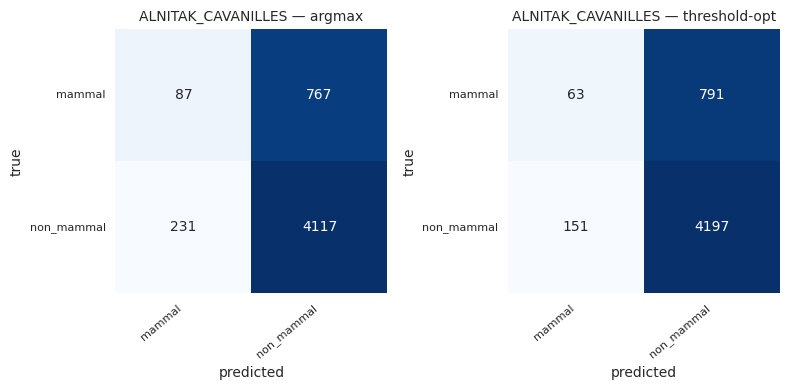


  Held out: Adriatic_Sea   |   classes present: ['mammal', 'non_mammal']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.472     0.391    -0.081
  test_macro_f1_full_vocab           0.472     0.391    -0.081
  test_weighted_f1                   0.495     0.387    -0.109
  test_accuracy                      0.475     0.391    -0.084
  test_balanced_acc                  0.668     0.617    -0.051

  Per-class thresholds optimized on val:
    mammal                          t*=0.540  val_F1=0.785
    non_mammal                      t*=0.160  val_F1=0.957


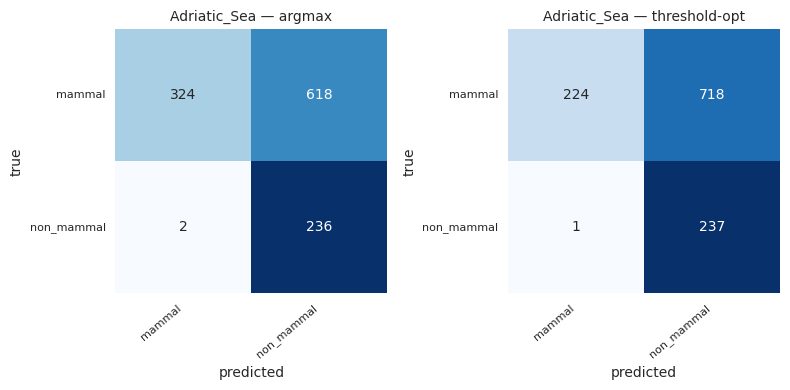


  Held out: DCLDE_2026   |   classes present: ['mammal', 'non_mammal']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.568     0.603    +0.035
  test_macro_f1_full_vocab           0.568     0.603    +0.035
  test_weighted_f1                   0.756     0.803    +0.047
  test_accuracy                      0.712     0.781    +0.069
  test_balanced_acc                  0.638     0.637    -0.001

  Per-class thresholds optimized on val:
    mammal                          t*=0.560  val_F1=0.437
    non_mammal                      t*=0.020  val_F1=0.855


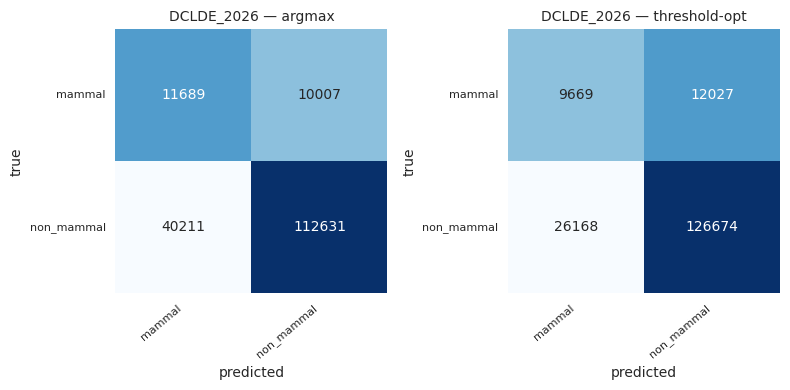


  Held out: DOLPHINFREE   |   classes present: ['mammal', 'non_mammal']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.735     0.758    +0.023
  test_macro_f1_full_vocab           0.735     0.758    +0.023
  test_weighted_f1                   0.745     0.772    +0.027
  test_accuracy                      0.740     0.767    +0.027
  test_balanced_acc                  0.771     0.779    +0.008

  Per-class thresholds optimized on val:
    mammal                          t*=0.580  val_F1=0.769
    non_mammal                      t*=0.160  val_F1=0.960


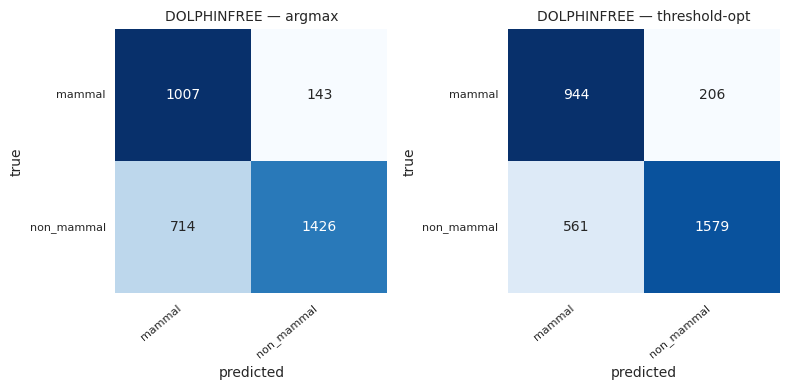


  Held out: DRYAD   |   classes present: ['mammal', 'non_mammal']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.764     0.775    +0.011
  test_macro_f1_full_vocab           0.764     0.775    +0.011
  test_weighted_f1                   0.767     0.779    +0.012
  test_accuracy                      0.766     0.778    +0.013
  test_balanced_acc                  0.769     0.778    +0.009

  Per-class thresholds optimized on val:
    mammal                          t*=0.500  val_F1=0.760
    non_mammal                      t*=0.120  val_F1=0.965


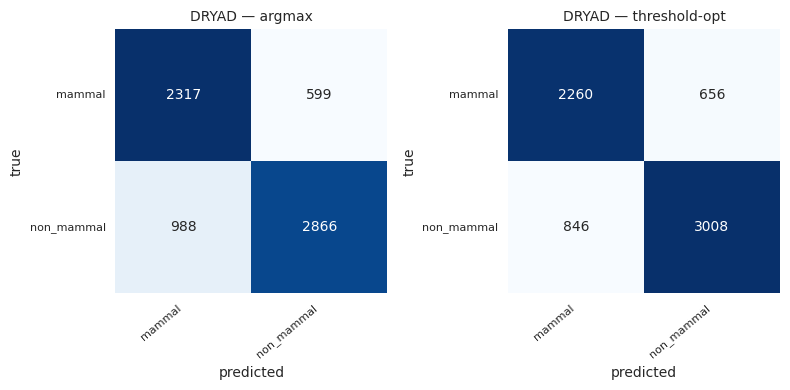


  Held out: ECOSS_annot   |   classes present: ['mammal', 'non_mammal']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.418     0.429    +0.011
  test_macro_f1_full_vocab           0.418     0.429    +0.011
  test_weighted_f1                   0.408     0.410    +0.002
  test_accuracy                      0.420     0.440    +0.020
  test_balanced_acc                  0.463     0.502    +0.040

  Per-class thresholds optimized on val:
    mammal                          t*=0.680  val_F1=0.762
    non_mammal                      t*=0.200  val_F1=0.964


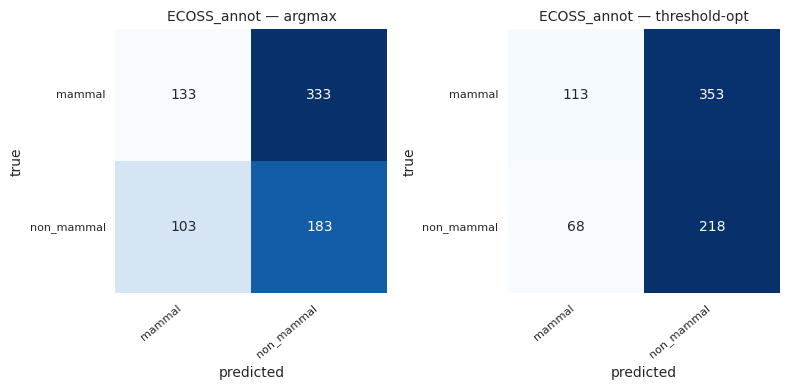


  Held out: ECOSS_enhanced   |   classes present: ['mammal', 'non_mammal']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.591     0.591    +0.000
  test_macro_f1_full_vocab           0.591     0.591    +0.000
  test_weighted_f1                   0.825     0.825    +0.000
  test_accuracy                      0.863     0.863    +0.000
  test_balanced_acc                  0.573     0.573    +0.000

  Per-class thresholds optimized on val:
    mammal                          t*=0.520  val_F1=0.736
    non_mammal                      t*=0.180  val_F1=0.955


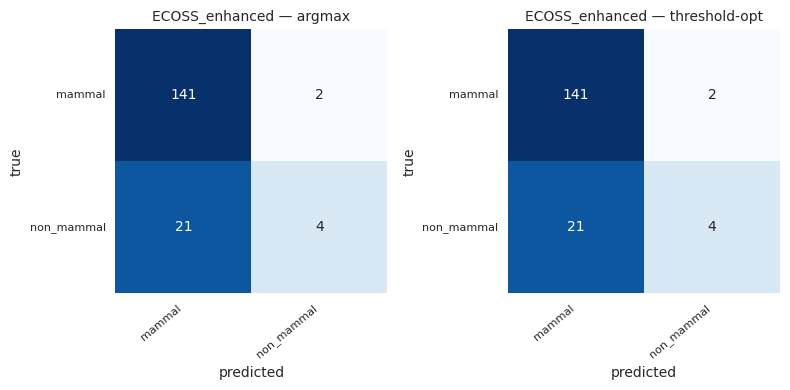


  Held out: ECOSS_testtrain   |   classes present: ['mammal', 'non_mammal']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.518     0.537    +0.018
  test_macro_f1_full_vocab           0.518     0.537    +0.018
  test_weighted_f1                   0.956     0.968    +0.012
  test_accuracy                      0.922     0.944    +0.023
  test_balanced_acc                  0.929     0.921    -0.008

  Per-class thresholds optimized on val:
    mammal                          t*=0.620  val_F1=0.778
    non_mammal                      t*=0.240  val_F1=0.949


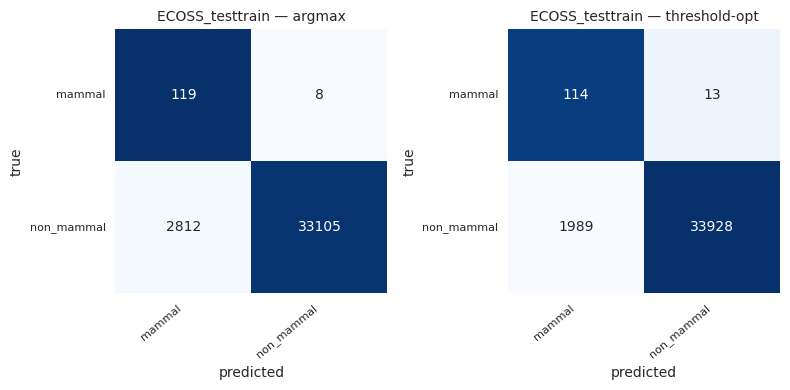


  Held out: FREMANTLE   |   classes present: ['mammal']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.867     0.801    -0.065
  test_macro_f1_full_vocab           0.433     0.401    -0.033
  test_weighted_f1                   0.867     0.801    -0.065
  test_accuracy                      0.765     0.669    -0.096
  test_balanced_acc                  0.765     0.669    -0.096

  Per-class thresholds optimized on val:
    mammal                          t*=0.700  val_F1=0.788
    non_mammal                      t*=0.200  val_F1=0.959


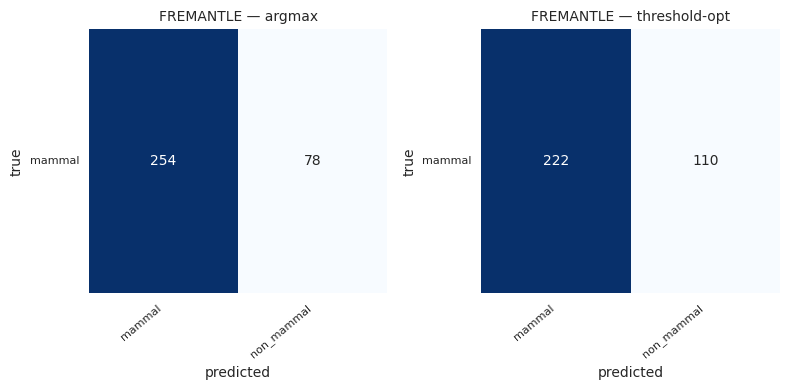


  Held out: MONISH   |   classes present: ['mammal']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.807     0.743    -0.063
  test_macro_f1_full_vocab           0.403     0.372    -0.032
  test_weighted_f1                   0.807     0.743    -0.063
  test_accuracy                      0.676     0.592    -0.084
  test_balanced_acc                  0.676     0.592    -0.084

  Per-class thresholds optimized on val:
    mammal                          t*=0.660  val_F1=0.743
    non_mammal                      t*=0.160  val_F1=0.958


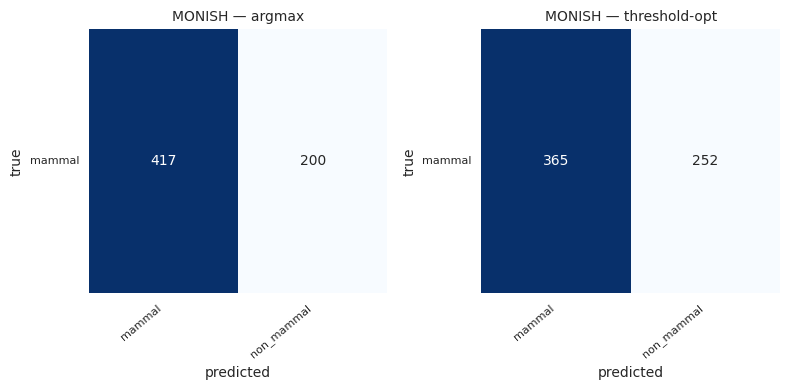


  Held out: OLTREMARE   |   classes present: ['mammal', 'non_mammal']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.826     0.826    -0.000
  test_macro_f1_full_vocab           0.826     0.826    -0.000
  test_weighted_f1                   0.905     0.906    +0.001
  test_accuracy                      0.910     0.912    +0.002
  test_balanced_acc                  0.796     0.791    -0.005

  Per-class thresholds optimized on val:
    mammal                          t*=0.460  val_F1=0.769
    non_mammal                      t*=0.220  val_F1=0.957


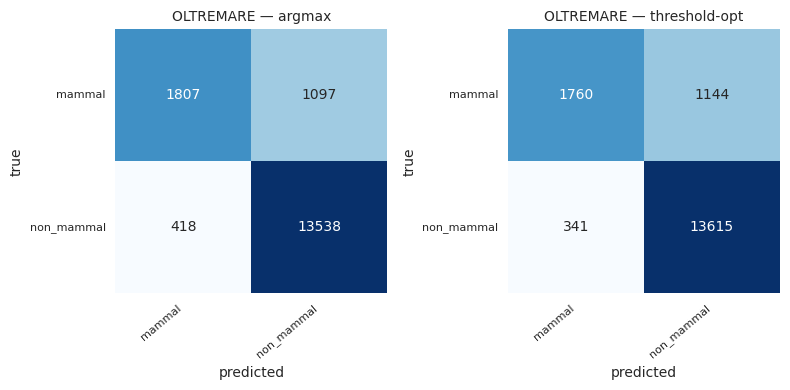


  Held out: WATKINS   |   classes present: ['mammal']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.651     0.607    -0.044
  test_macro_f1_full_vocab           0.325     0.304    -0.022
  test_weighted_f1                   0.651     0.607    -0.044
  test_accuracy                      0.482     0.436    -0.046
  test_balanced_acc                  0.482     0.436    -0.046

  Per-class thresholds optimized on val:
    mammal                          t*=0.640  val_F1=0.743
    non_mammal                      t*=0.140  val_F1=0.957


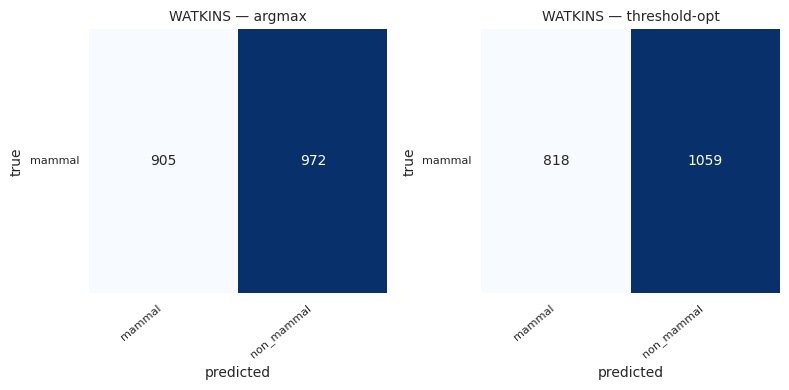

In [13]:
for ds, r in results_l1.items():
    report_comparison(ds, r['class_names'], r['yte'],
                      r['y_argmax'], r['y_thresh'],
                      r['thresholds'], r['sweep_data'])

In [14]:
summary_l1 = make_summary_df(results_l1, 'L1-binary')
print("\nLevel 1 summary:")
print(summary_l1[['held_out','n_test','argmax_macro_f1','thresh_macro_f1',
                   'delta_macro_f1','argmax_balanced_acc','thresh_balanced_acc']].to_string(index=False))
summary_l1.to_csv(OUT_DIR / 'summary_l1_binary_lodo.csv', index=False)


Level 1 summary:
          held_out  n_test  argmax_macro_f1  thresh_macro_f1  delta_macro_f1  argmax_balanced_acc  thresh_balanced_acc
         OLTREMARE   16860         0.825816         0.825791       -0.000025             0.796147             0.790813
         FREMANTLE     332         0.866894         0.801444       -0.065450             0.765060             0.668675
             DRYAD    6770         0.764032         0.775397        0.011365             0.769112             0.777761
       DOLPHINFREE    3290         0.735219         0.757849        0.022629             0.771004             0.779360
            MONISH     617         0.806576         0.743381       -0.063196             0.675851             0.591572
           WATKINS    1877         0.650611         0.607050       -0.043561             0.482152             0.435802
        DCLDE_2026  174538         0.567680         0.602555        0.034875             0.637837             0.637224
    ECOSS_enhanced     168    

## 5. Level 2 — coarse group LODO

`odontocete / mysticete / anthropogenic / background`

In [15]:
L2_HOLDOUTS = sorted(meta_l2['dataset'].unique().tolist())
print(f"Level 2 holdouts ({len(L2_HOLDOUTS)}): {L2_HOLDOUTS}")
print()
print(pd.crosstab(meta_l2['dataset'], meta_l2['label']).to_string())

Level 2 holdouts (12): ['ALNITAK_CAVANILLES', 'Adriatic_Sea', 'DCLDE_2026', 'DOLPHINFREE', 'DRYAD', 'ECOSS_annot', 'ECOSS_enhanced', 'ECOSS_testtrain', 'FREMANTLE', 'MONISH', 'OLTREMARE', 'WATKINS']

label               anthropogenic  background  mysticete  odontocete
dataset                                                             
ALNITAK_CAVANILLES              0        4348          0         854
Adriatic_Sea                    0         238          0         942
DCLDE_2026                      0      152842          0       21696
DOLPHINFREE                     0        2140          0        1150
DRYAD                           0        3854          0        2916
ECOSS_annot                   286           0          0         466
ECOSS_enhanced                 25           0          0         143
ECOSS_testtrain             33585        2332          0         127
FREMANTLE                       0           0          0         332
MONISH                          0        

In [16]:
results_l2 = run_lodo_level(meta_l2, 'label', 'L2-coarse', L2_HOLDOUTS,
                             min_train_per_class=5, verbose=True)

L2-coarse LODO:   0%|          | 0/12 [00:00<?, ?it/s]


  [ALNITAK_CAVANILLES] training classes (4): ['anthropogenic', 'background', 'mysticete', 'odontocete']
  [ALNITAK_CAVANILLES] test composition:
      background                       n= 4,348  (OK)
      odontocete                       n=   854  (OK)
  [ALNITAK_CAVANILLES] train=216,635  val=25,793  test=5,202

  [Adriatic_Sea] training classes (4): ['anthropogenic', 'background', 'mysticete', 'odontocete']
  [Adriatic_Sea] test composition:
      odontocete                       n=   942  (OK)
      background                       n=   238  (OK)
  [Adriatic_Sea] train=222,878  val=23,572  test=1,180

  [DCLDE_2026] training classes (4): ['anthropogenic', 'background', 'mysticete', 'odontocete']
  [DCLDE_2026] test composition:
      background                       n=152,842  (OK)
      odontocete                       n=21,696  (OK)
  [DCLDE_2026] train=63,694  val=9,398  test=174,538

  [DOLPHINFREE] training classes (4): ['anthropogenic', 'background', 'mysticete', 'odontocete'


  Held out: ALNITAK_CAVANILLES   |   classes present: ['background', 'odontocete']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.520     0.517    -0.003
  test_macro_f1_full_vocab           0.260     0.258    -0.002
  test_weighted_f1                   0.753     0.775    +0.022
  test_accuracy                      0.770     0.822    +0.052
  test_balanced_acc                  0.520     0.525    +0.005

  Per-class thresholds optimized on val:
    anthropogenic                   t*=0.640  val_F1=0.998
    background                      t*=0.100  val_F1=0.958
    mysticete                       t*=0.040  val_F1=0.953
    odontocete                      t*=0.780  val_F1=0.772


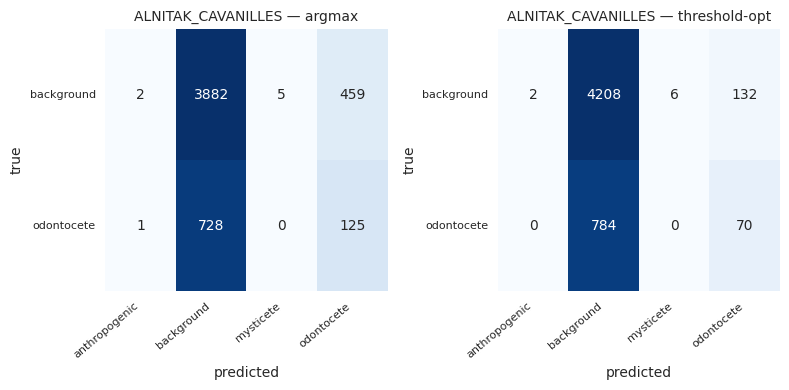


  Held out: Adriatic_Sea   |   classes present: ['background', 'odontocete']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.700     0.461    -0.239
  test_macro_f1_full_vocab           0.350     0.231    -0.119
  test_weighted_f1                   0.762     0.482    -0.279
  test_accuracy                      0.736     0.464    -0.272
  test_balanced_acc                  0.823     0.659    -0.164

  Per-class thresholds optimized on val:
    anthropogenic                   t*=0.680  val_F1=0.999
    background                      t*=0.120  val_F1=0.955
    mysticete                       t*=0.080  val_F1=1.000
    odontocete                      t*=0.800  val_F1=0.800


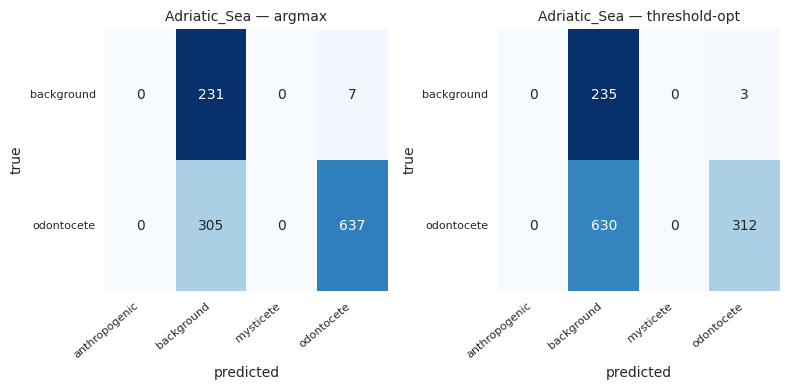


  Held out: DCLDE_2026   |   classes present: ['background', 'odontocete']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.502     0.521    +0.018
  test_macro_f1_full_vocab           0.251     0.260    +0.009
  test_weighted_f1                   0.674     0.704    +0.031
  test_accuracy                      0.600     0.640    +0.040
  test_balanced_acc                  0.551     0.559    +0.007

  Per-class thresholds optimized on val:
    anthropogenic                   t*=0.280  val_F1=1.000
    background                      t*=0.020  val_F1=0.811
    mysticete                       t*=0.220  val_F1=1.000
    odontocete                      t*=0.220  val_F1=0.427


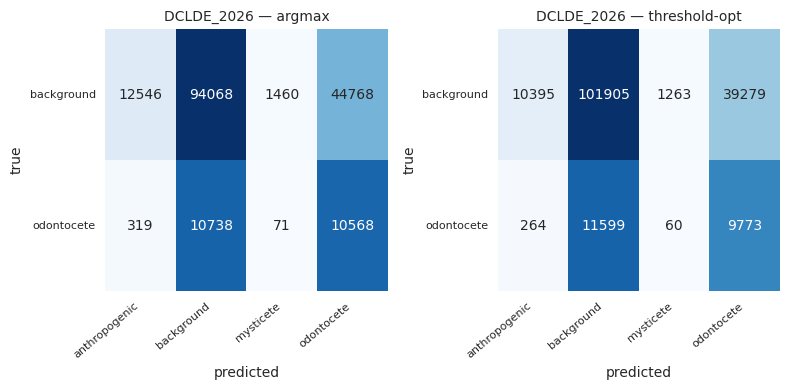


  Held out: DOLPHINFREE   |   classes present: ['background', 'odontocete']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.699     0.836    +0.138
  test_macro_f1_full_vocab           0.349     0.418    +0.069
  test_weighted_f1                   0.696     0.844    +0.148
  test_accuracy                      0.684     0.834    +0.150
  test_balanced_acc                  0.749     0.855    +0.106

  Per-class thresholds optimized on val:
    anthropogenic                   t*=0.780  val_F1=0.997
    background                      t*=0.160  val_F1=0.953
    mysticete                       t*=0.580  val_F1=1.000
    odontocete                      t*=0.740  val_F1=0.764


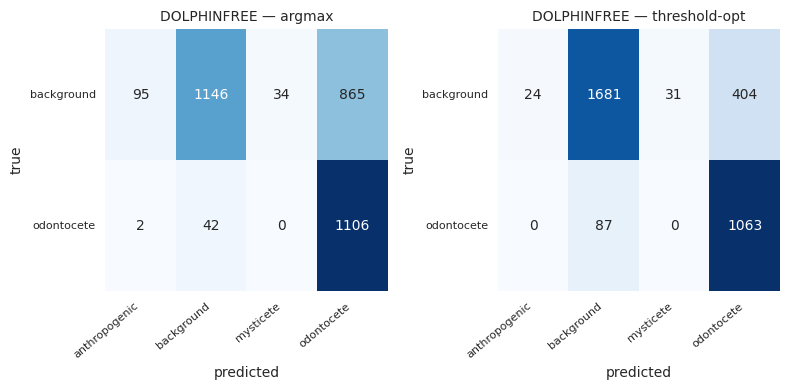


  Held out: DRYAD   |   classes present: ['background', 'odontocete']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.715     0.771    +0.056
  test_macro_f1_full_vocab           0.357     0.386    +0.028
  test_weighted_f1                   0.715     0.775    +0.060
  test_accuracy                      0.701     0.757    +0.056
  test_balanced_acc                  0.720     0.762    +0.042

  Per-class thresholds optimized on val:
    anthropogenic                   t*=0.020  val_F1=0.999
    background                      t*=0.120  val_F1=0.964
    mysticete                       t*=0.020  val_F1=0.982
    odontocete                      t*=0.760  val_F1=0.771


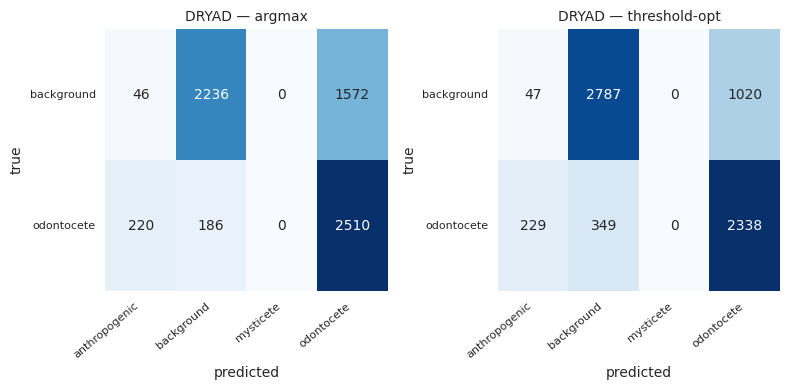


  Held out: ECOSS_annot   |   classes present: ['anthropogenic', 'odontocete']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.195     0.189    -0.006
  test_macro_f1_full_vocab           0.097     0.094    -0.003
  test_weighted_f1                   0.242     0.234    -0.007
  test_accuracy                      0.193     0.162    -0.031
  test_balanced_acc                  0.156     0.131    -0.025

  Per-class thresholds optimized on val:
    anthropogenic                   t*=0.480  val_F1=0.999
    background                      t*=0.160  val_F1=0.960
    mysticete                       t*=0.060  val_F1=1.000
    odontocete                      t*=0.680  val_F1=0.769


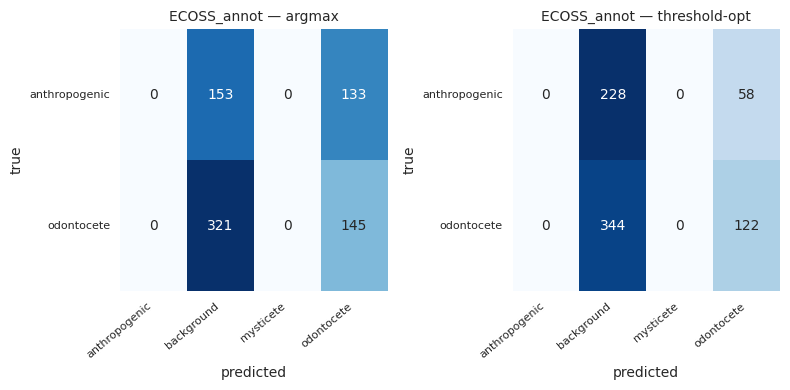


  Held out: ECOSS_enhanced   |   classes present: ['anthropogenic', 'odontocete']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.636     0.633    -0.004
  test_macro_f1_full_vocab           0.318     0.316    -0.002
  test_weighted_f1                   0.889     0.883    -0.006
  test_accuracy                      0.869     0.857    -0.012
  test_balanced_acc                  0.577     0.570    -0.007

  Per-class thresholds optimized on val:
    anthropogenic                   t*=0.140  val_F1=1.000
    background                      t*=0.220  val_F1=0.953
    mysticete                       t*=0.020  val_F1=1.000
    odontocete                      t*=0.640  val_F1=0.753


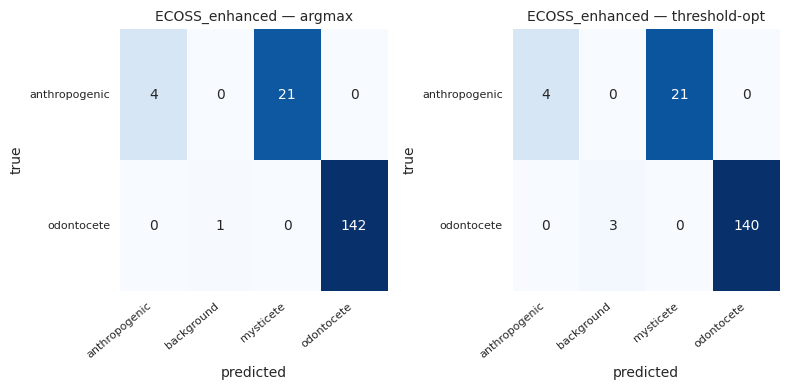


  Held out: ECOSS_testtrain   |   classes present: ['anthropogenic', 'background', 'odontocete']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.053     0.068    +0.015
  test_macro_f1_full_vocab           0.040     0.051    +0.011
  test_weighted_f1                   0.009     0.009    -0.001
  test_accuracy                      0.058     0.062    +0.004
  test_balanced_acc                  0.586     0.574    -0.012

  Per-class thresholds optimized on val:
    anthropogenic                   t*=0.780  val_F1=0.500
    background                      t*=0.180  val_F1=0.952
    mysticete                       t*=0.320  val_F1=1.000
    odontocete                      t*=0.760  val_F1=0.789


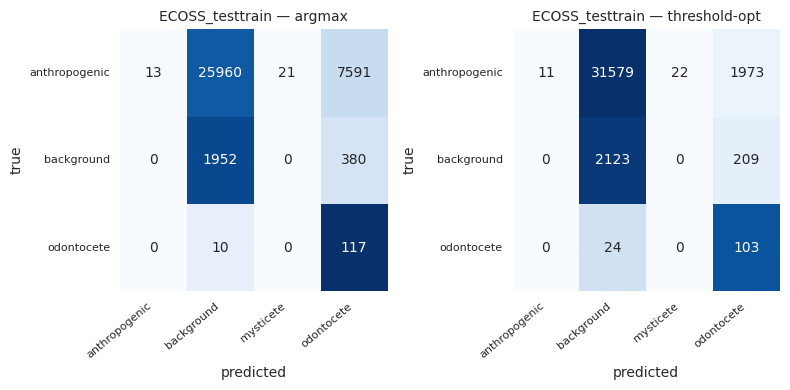


  Held out: FREMANTLE   |   classes present: ['odontocete']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.910     0.810    -0.100
  test_macro_f1_full_vocab           0.227     0.203    -0.025
  test_weighted_f1                   0.910     0.810    -0.100
  test_accuracy                      0.834     0.681    -0.154
  test_balanced_acc                  0.834     0.681    -0.154

  Per-class thresholds optimized on val:
    anthropogenic                   t*=0.020  val_F1=0.991
    background                      t*=0.260  val_F1=0.952
    mysticete                       t*=0.020  val_F1=0.984
    odontocete                      t*=0.600  val_F1=0.784


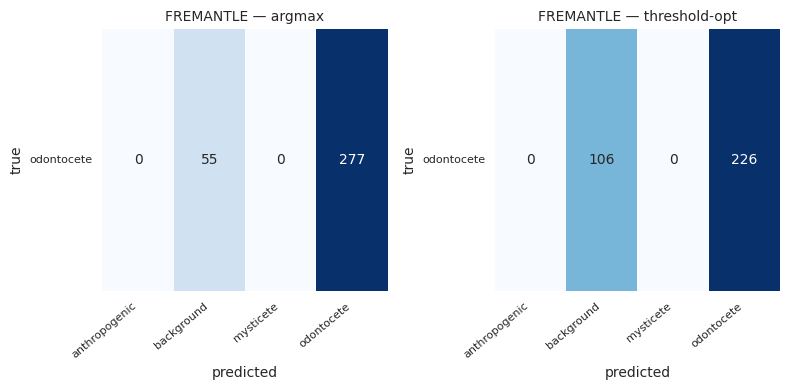


  Held out: MONISH   |   classes present: ['mysticete', 'odontocete']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.430     0.382    -0.048
  test_macro_f1_full_vocab           0.215     0.191    -0.024
  test_weighted_f1                   0.819     0.727    -0.091
  test_accuracy                      0.741     0.603    -0.138
  test_balanced_acc                  0.389     0.316    -0.072

  Per-class thresholds optimized on val:
    anthropogenic                   t*=0.780  val_F1=0.999
    background                      t*=0.140  val_F1=0.953
    mysticete                       t*=0.240  val_F1=0.800
    odontocete                      t*=0.760  val_F1=0.751


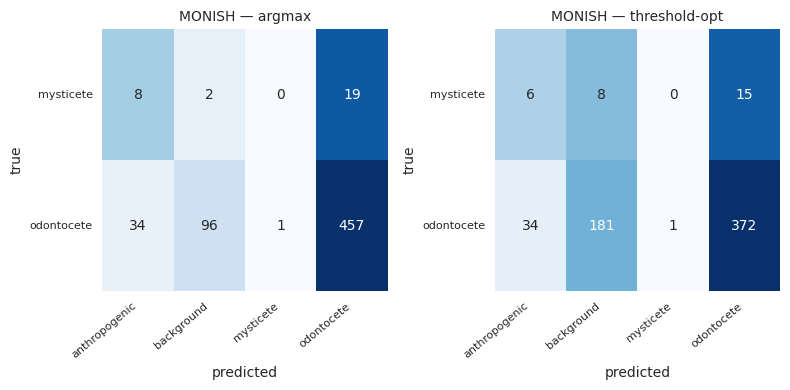


  Held out: OLTREMARE   |   classes present: ['background', 'odontocete']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.807     0.820    +0.014
  test_macro_f1_full_vocab           0.403     0.410    +0.007
  test_weighted_f1                   0.888     0.904    +0.016
  test_accuracy                      0.887     0.911    +0.024
  test_balanced_acc                  0.814     0.781    -0.033

  Per-class thresholds optimized on val:
    anthropogenic                   t*=0.760  val_F1=0.999
    background                      t*=0.160  val_F1=0.948
    mysticete                       t*=0.640  val_F1=0.980
    odontocete                      t*=0.740  val_F1=0.763


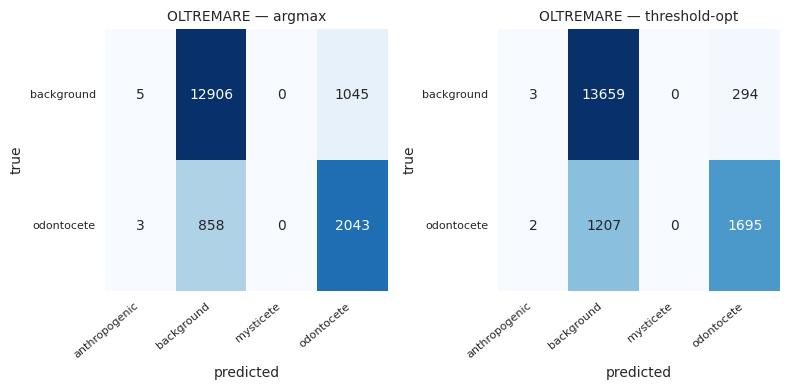


  Held out: WATKINS   |   classes present: ['mysticete', 'odontocete']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.469     0.437    -0.031
  test_macro_f1_full_vocab           0.234     0.219    -0.016
  test_weighted_f1                   0.674     0.629    -0.045
  test_accuracy                      0.637     0.560    -0.077
  test_balanced_acc                  0.443     0.389    -0.054

  Per-class thresholds optimized on val:
    anthropogenic                   t*=0.100  val_F1=1.000
    background                      t*=0.180  val_F1=0.952
    mysticete                       t*=0.040  val_F1=1.000
    odontocete                      t*=0.760  val_F1=0.758


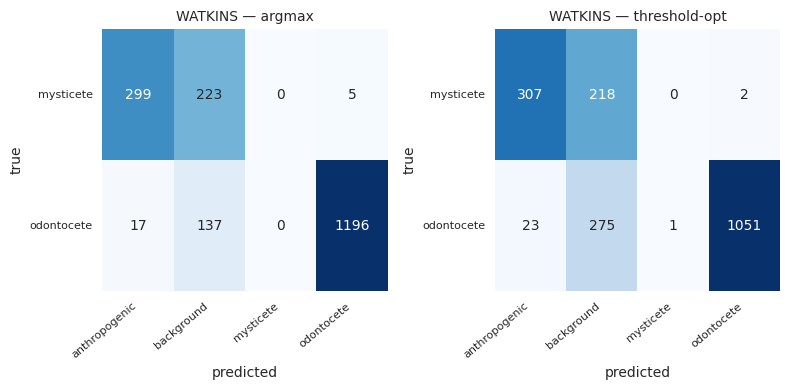

In [17]:
for ds, r in results_l2.items():
    report_comparison(ds, r['class_names'], r['yte'],
                      r['y_argmax'], r['y_thresh'],
                      r['thresholds'], r['sweep_data'])

In [18]:
summary_l2 = make_summary_df(results_l2, 'L2-coarse')
print("\nLevel 2 summary:")
print(summary_l2[['held_out','n_test','n_classes_test','argmax_macro_f1',
                   'thresh_macro_f1','delta_macro_f1','argmax_balanced_acc',
                   'thresh_balanced_acc']].to_string(index=False))
summary_l2.to_csv(OUT_DIR / 'summary_l2_coarse_lodo.csv', index=False)


Level 2 summary:
          held_out  n_test  n_classes_test  argmax_macro_f1  thresh_macro_f1  delta_macro_f1  argmax_balanced_acc  thresh_balanced_acc
       DOLPHINFREE    3290               2         0.698725         0.836334        0.137609             0.748627             0.854931
         OLTREMARE   16860               2         0.806539         0.820322        0.013783             0.814138             0.781198
         FREMANTLE     332               1         0.909688         0.810036       -0.099652             0.834337             0.680723
             DRYAD    6770               2         0.714952         0.771361        0.056410             0.720472             0.762464
    ECOSS_enhanced     168               2         0.636177         0.632631       -0.003546             0.576503             0.569510
        DCLDE_2026  174538               2         0.502293         0.520742        0.018449             0.551277             0.558593
ALNITAK_CAVANILLES    5202           

## 6. Level 4 — species LODO

All species (`label_t4`) + background. Same joint label as the previous notebook.

In [19]:
L4_HOLDOUTS = sorted(meta_l4['dataset'].unique().tolist())
print(f"Level 4 holdouts ({len(L4_HOLDOUTS)}): {L4_HOLDOUTS}")
print()
print("Class counts per dataset (level 4):")
print(pd.crosstab(meta_l4['dataset'], meta_l4['label']).to_string())

Level 4 holdouts (12): ['ALNITAK_CAVANILLES', 'Adriatic_Sea', 'DCLDE_2026', 'DOLPHINFREE', 'DRYAD', 'ECOSS_annot', 'ECOSS_enhanced', 'ECOSS_testtrain', 'FREMANTLE', 'MONISH', 'OLTREMARE', 'WATKINS']

Class counts per dataset (level 4):
label               Balaenoptera_acutorostrata  Balaenoptera_physalus  Delphinidae_unknown  Delphinus_delphis  Globicephala_melas  Grampus_griseus  Orcinus_orca  Physeter_macrocephalus  Stenella_coeruleoalba  Tursiops_truncatus  background
dataset                                                                                                                                                                                                                                        
ALNITAK_CAVANILLES                           0                      0                    0                  0                 141               45             0                     179                     15                  58        4348
Adriatic_Sea                                

In [20]:
results_l4 = run_lodo_level(meta_l4, 'label', 'L4-species', L4_HOLDOUTS,
                             min_train_per_class=5, verbose=True)

L4-species LODO:   0%|          | 0/12 [00:00<?, ?it/s]


  [ALNITAK_CAVANILLES] training classes (11): ['Balaenoptera_acutorostrata', 'Balaenoptera_physalus', 'Delphinidae_unknown', 'Delphinus_delphis', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus', 'background']
  [ALNITAK_CAVANILLES] test composition:
      background                       n= 4,348  (OK)
      Physeter_macrocephalus           n=   179  (OK)
      Globicephala_melas               n=   141  (OK)
      Tursiops_truncatus               n=    58  (OK)
      Grampus_griseus                  n=    45  (OK)
      Stenella_coeruleoalba            n=    15  (OK)
  [ALNITAK_CAVANILLES] train=216,635  val=25,793  test=4,786

  [Adriatic_Sea] training classes (11): ['Balaenoptera_acutorostrata', 'Balaenoptera_physalus', 'Delphinidae_unknown', 'Delphinus_delphis', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus', 'background'


  Held out: ALNITAK_CAVANILLES   |   classes present: ['Globicephala_melas', 'Grampus_griseus', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus', 'background']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.183     0.184    +0.002
  test_macro_f1_full_vocab           0.100     0.101    +0.001
  test_weighted_f1                   0.838     0.855    +0.016
  test_accuracy                      0.835     0.872    +0.037
  test_balanced_acc                  0.169     0.175    +0.006

  Per-class thresholds optimized on val:
    Balaenoptera_acutorostrata      t*=0.420  val_F1=1.000
    Balaenoptera_physalus           t*=0.320  val_F1=1.000
    Delphinidae_unknown             t*=0.320  val_F1=0.933
    Delphinus_delphis               t*=0.800  val_F1=0.811
    Globicephala_melas              t*=0.380  val_F1=0.913
    Grampus_griseus                 t*=0

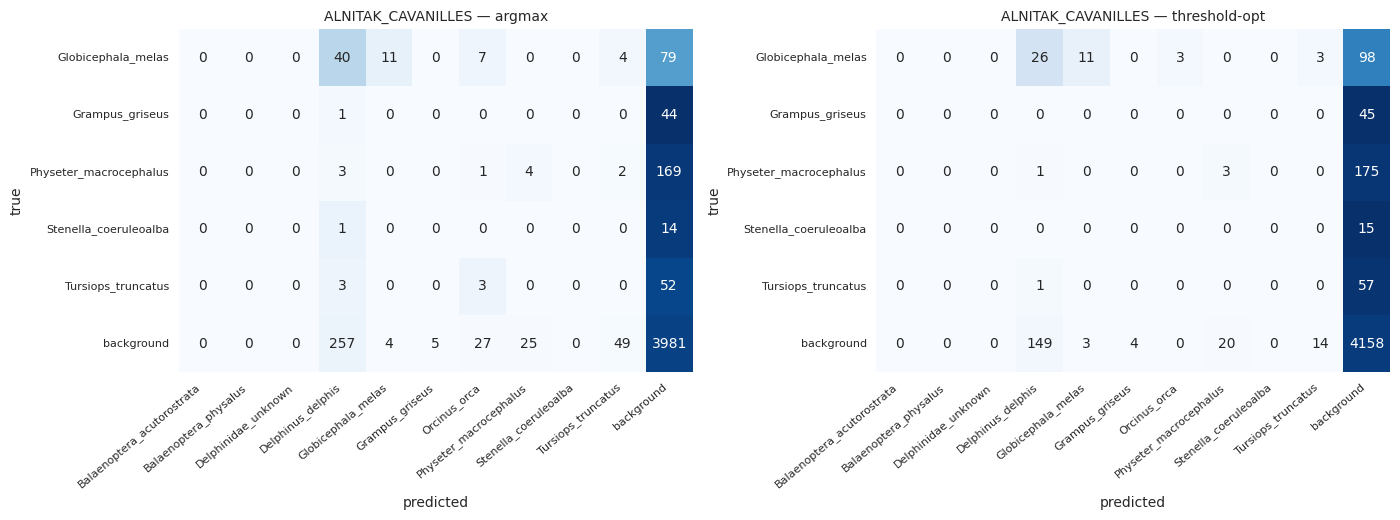


  Held out: Adriatic_Sea   |   classes present: ['Tursiops_truncatus', 'background']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.734     0.661    -0.073
  test_macro_f1_full_vocab           0.133     0.120    -0.013
  test_weighted_f1                   0.799     0.722    -0.078
  test_accuracy                      0.773     0.691    -0.082
  test_balanced_acc                  0.795     0.791    -0.004

  Per-class thresholds optimized on val:
    Balaenoptera_acutorostrata      t*=0.220  val_F1=1.000
    Balaenoptera_physalus           t*=0.800  val_F1=0.895
    Delphinidae_unknown             t*=0.740  val_F1=0.846
    Delphinus_delphis               t*=0.800  val_F1=0.876
    Globicephala_melas              t*=0.760  val_F1=0.425
    Grampus_griseus                 t*=0.740  val_F1=0.867
    Orcinus_orca                    t*=0.800  val_F1=0.734
    Physeter_macroce

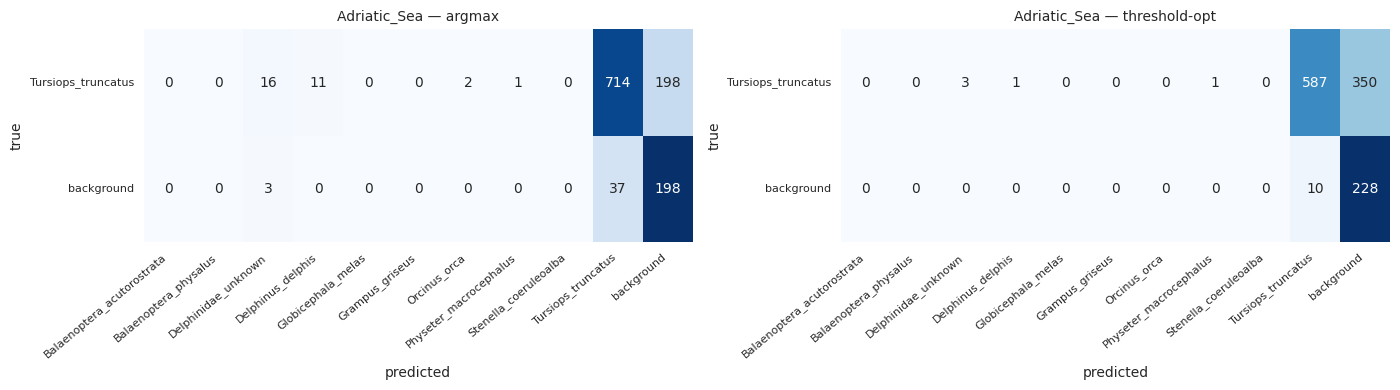


  Held out: DCLDE_2026   |   classes present: ['Orcinus_orca', 'background']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.521     0.537    +0.016
  test_macro_f1_full_vocab           0.095     0.098    +0.003
  test_weighted_f1                   0.681     0.719    +0.037
  test_accuracy                      0.561     0.614    +0.053
  test_balanced_acc                  0.420     0.444    +0.024

  Per-class thresholds optimized on val:
    Balaenoptera_acutorostrata      t*=0.240  val_F1=1.000
    Balaenoptera_physalus           t*=0.780  val_F1=0.994
    Delphinidae_unknown             t*=0.560  val_F1=0.537
    Delphinus_delphis               t*=0.800  val_F1=0.677
    Globicephala_melas              t*=0.140  val_F1=0.917
    Grampus_griseus                 t*=0.580  val_F1=1.000
    Orcinus_orca                    t*=0.400  val_F1=1.000
    Physeter_macrocephalus  

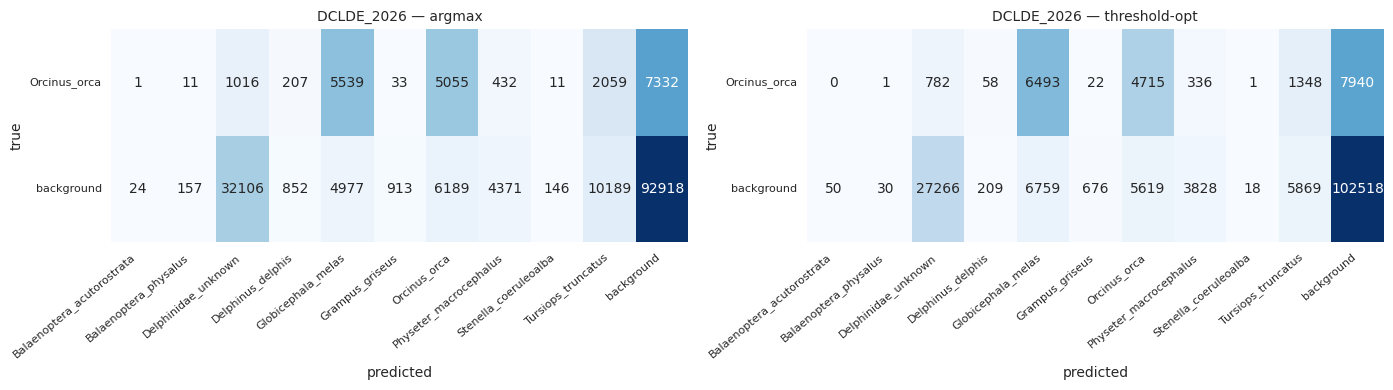


  Held out: DOLPHINFREE   |   classes present: ['Delphinus_delphis', 'background']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.346     0.410    +0.065
  test_macro_f1_full_vocab           0.063     0.075    +0.012
  test_weighted_f1                   0.405     0.520    +0.115
  test_accuracy                      0.278     0.522    +0.243
  test_balanced_acc                  0.233     0.407    +0.174

  Per-class thresholds optimized on val:
    Balaenoptera_acutorostrata      t*=0.500  val_F1=0.000
    Balaenoptera_physalus           t*=0.440  val_F1=0.980
    Delphinidae_unknown             t*=0.720  val_F1=0.874
    Delphinus_delphis               t*=0.760  val_F1=0.375
    Globicephala_melas              t*=0.780  val_F1=0.824
    Grampus_griseus                 t*=0.800  val_F1=0.775
    Orcinus_orca                    t*=0.800  val_F1=0.697
    Physeter_macroceph

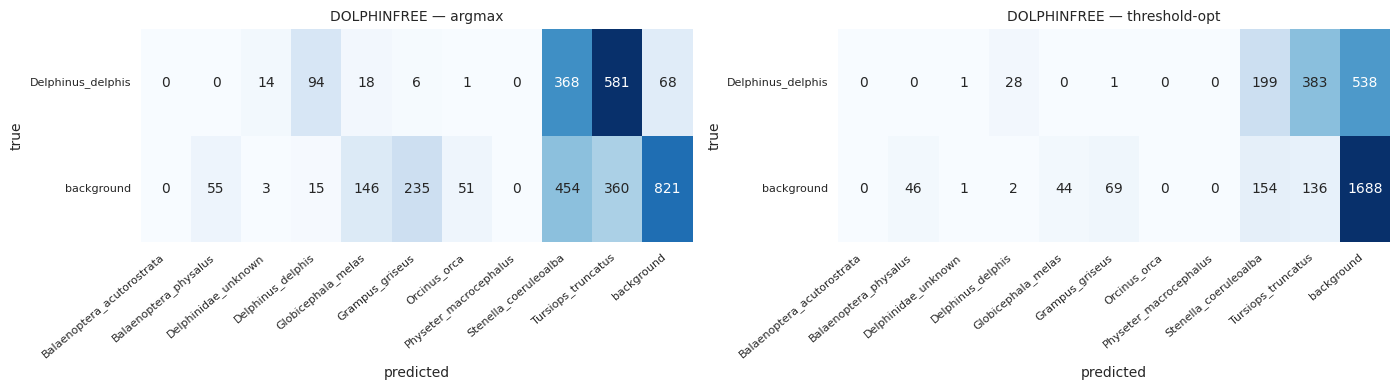


  Held out: DRYAD   |   classes present: ['Tursiops_truncatus', 'background']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.669     0.712    +0.042
  test_macro_f1_full_vocab           0.122     0.129    +0.008
  test_weighted_f1                   0.672     0.721    +0.050
  test_accuracy                      0.594     0.693    +0.099
  test_balanced_acc                  0.599     0.674    +0.076

  Per-class thresholds optimized on val:
    Balaenoptera_acutorostrata      t*=0.080  val_F1=0.667
    Balaenoptera_physalus           t*=0.580  val_F1=1.000
    Delphinidae_unknown             t*=0.740  val_F1=0.906
    Delphinus_delphis               t*=0.660  val_F1=0.829
    Globicephala_melas              t*=0.260  val_F1=0.420
    Grampus_griseus                 t*=0.680  val_F1=0.818
    Orcinus_orca                    t*=0.800  val_F1=0.692
    Physeter_macrocephalus 

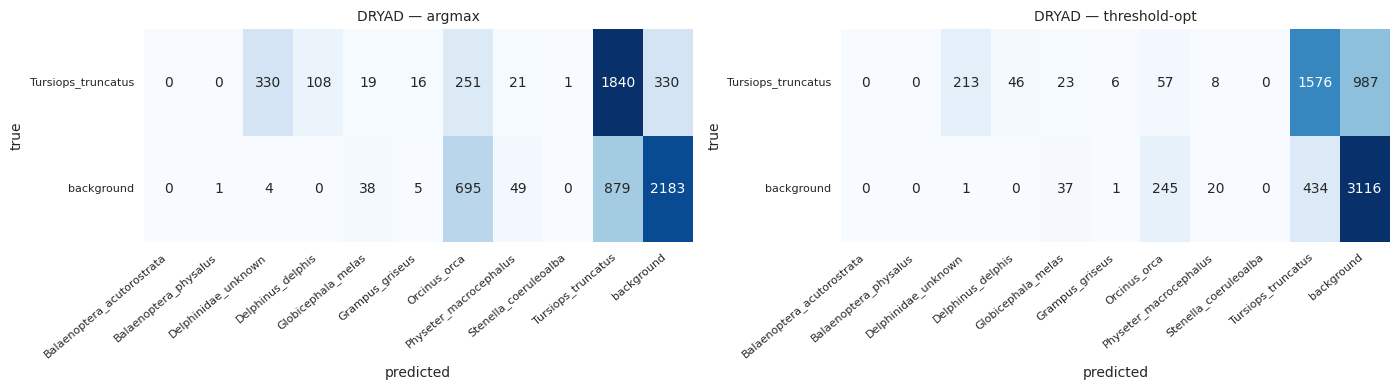


  Held out: ECOSS_annot   |   classes present: ['Delphinidae_unknown', 'background']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.300     0.320    +0.020
  test_macro_f1_full_vocab           0.055     0.058    +0.004
  test_weighted_f1                   0.228     0.243    +0.015
  test_accuracy                      0.269     0.354    +0.085
  test_balanced_acc                  0.353     0.465    +0.112

  Per-class thresholds optimized on val:
    Balaenoptera_acutorostrata      t*=0.500  val_F1=0.000
    Balaenoptera_physalus           t*=0.420  val_F1=1.000
    Delphinidae_unknown             t*=0.300  val_F1=0.400
    Delphinus_delphis               t*=0.800  val_F1=0.728
    Globicephala_melas              t*=0.560  val_F1=0.448
    Grampus_griseus                 t*=0.760  val_F1=0.909
    Orcinus_orca                    t*=0.700  val_F1=0.706
    Physeter_macroce

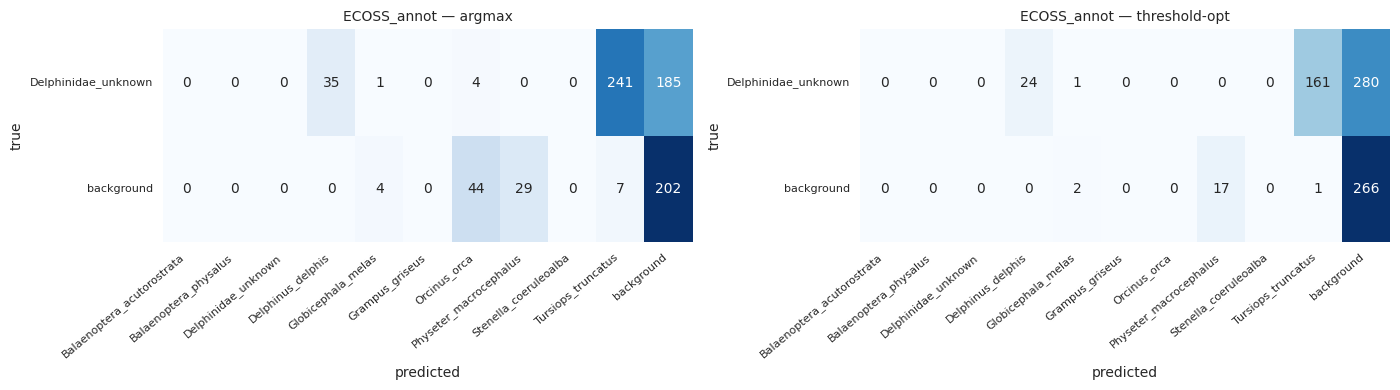


  Held out: ECOSS_enhanced   |   classes present: ['Delphinidae_unknown', 'Orcinus_orca', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus', 'background']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.530     0.514    -0.016
  test_macro_f1_full_vocab           0.289     0.280    -0.009
  test_weighted_f1                   0.367     0.354    -0.013
  test_accuracy                      0.351     0.333    -0.018
  test_balanced_acc                  0.514     0.491    -0.023

  Per-class thresholds optimized on val:
    Balaenoptera_acutorostrata      t*=0.120  val_F1=1.000
    Balaenoptera_physalus           t*=0.380  val_F1=1.000
    Delphinidae_unknown             t*=0.600  val_F1=0.991
    Delphinus_delphis               t*=0.780  val_F1=0.771
    Globicephala_melas              t*=0.360  val_F1=0.750
    Grampus_griseus                 t*=0.660  

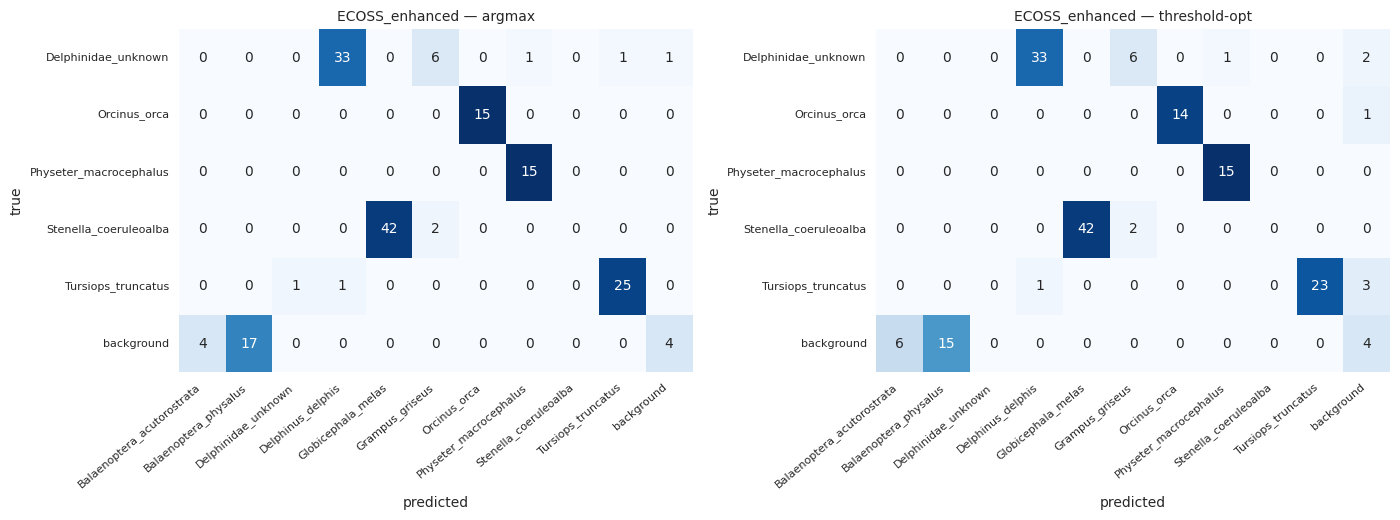


  Held out: ECOSS_testtrain   |   classes present: ['Delphinus_delphis', 'Globicephala_melas', 'Orcinus_orca', 'Physeter_macrocephalus', 'Tursiops_truncatus', 'background']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.249     0.410    +0.161
  test_macro_f1_full_vocab           0.136     0.224    +0.088
  test_weighted_f1                   0.960     0.988    +0.027
  test_accuracy                      0.928     0.979    +0.052
  test_balanced_acc                  0.652     0.574    -0.078

  Per-class thresholds optimized on val:
    Balaenoptera_acutorostrata      t*=0.080  val_F1=1.000
    Balaenoptera_physalus           t*=0.440  val_F1=1.000
    Delphinidae_unknown             t*=0.760  val_F1=0.955
    Delphinus_delphis               t*=0.800  val_F1=0.764
    Globicephala_melas              t*=0.800  val_F1=0.773
    Grampus_griseus                 t*=0.640  val_

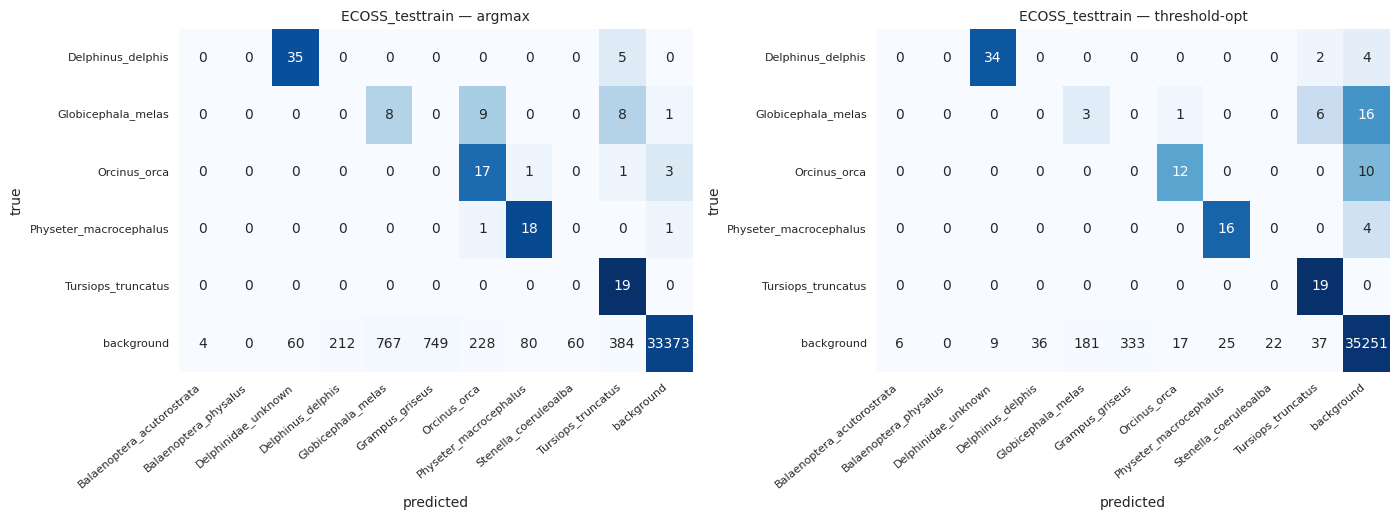


  Held out: FREMANTLE   |   classes present: ['Tursiops_truncatus']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.449     0.253    -0.196
  test_macro_f1_full_vocab           0.041     0.023    -0.018
  test_weighted_f1                   0.449     0.253    -0.196
  test_accuracy                      0.289     0.145    -0.145
  test_balanced_acc                  0.289     0.145    -0.145

  Per-class thresholds optimized on val:
    Balaenoptera_acutorostrata      t*=0.020  val_F1=0.800
    Balaenoptera_physalus           t*=0.440  val_F1=0.986
    Delphinidae_unknown             t*=0.320  val_F1=0.743
    Delphinus_delphis               t*=0.720  val_F1=0.868
    Globicephala_melas              t*=0.760  val_F1=0.424
    Grampus_griseus                 t*=0.340  val_F1=0.867
    Orcinus_orca                    t*=0.800  val_F1=0.691
    Physeter_macrocephalus          t

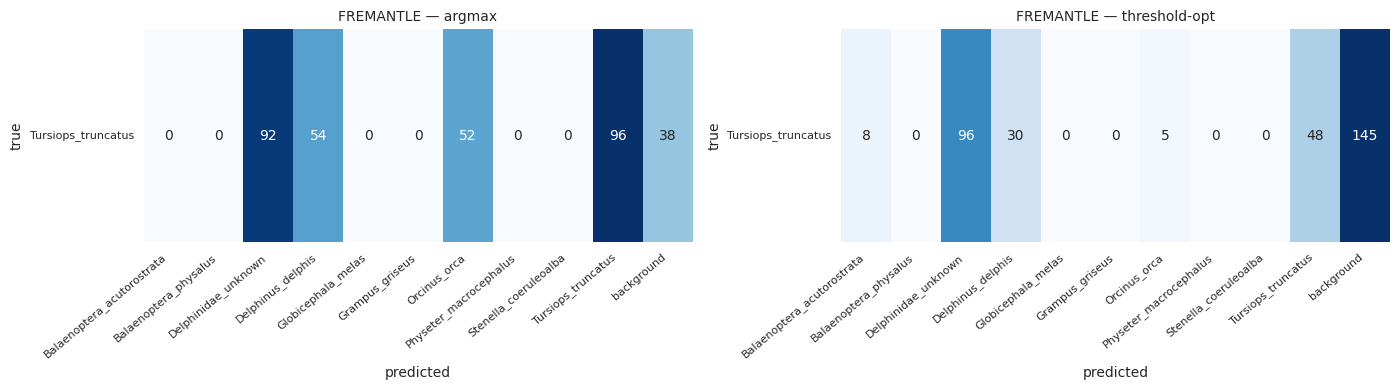


  Held out: MONISH   |   classes present: ['Balaenoptera_physalus', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Tursiops_truncatus']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.073     0.066    -0.006
  test_macro_f1_full_vocab           0.033     0.030    -0.003
  test_weighted_f1                   0.059     0.068    +0.009
  test_accuracy                      0.066     0.058    -0.008
  test_balanced_acc                  0.151     0.103    -0.048

  Per-class thresholds optimized on val:
    Balaenoptera_acutorostrata      t*=0.460  val_F1=0.500
    Balaenoptera_physalus           t*=0.800  val_F1=0.923
    Delphinidae_unknown             t*=0.360  val_F1=0.780
    Delphinus_delphis               t*=0.800  val_F1=0.700
    Globicephala_melas              t*=0.060  val_F1=0.732
    Grampus_griseus                 t*=0.560  val_F1=0.692
    Orcinus_orca 

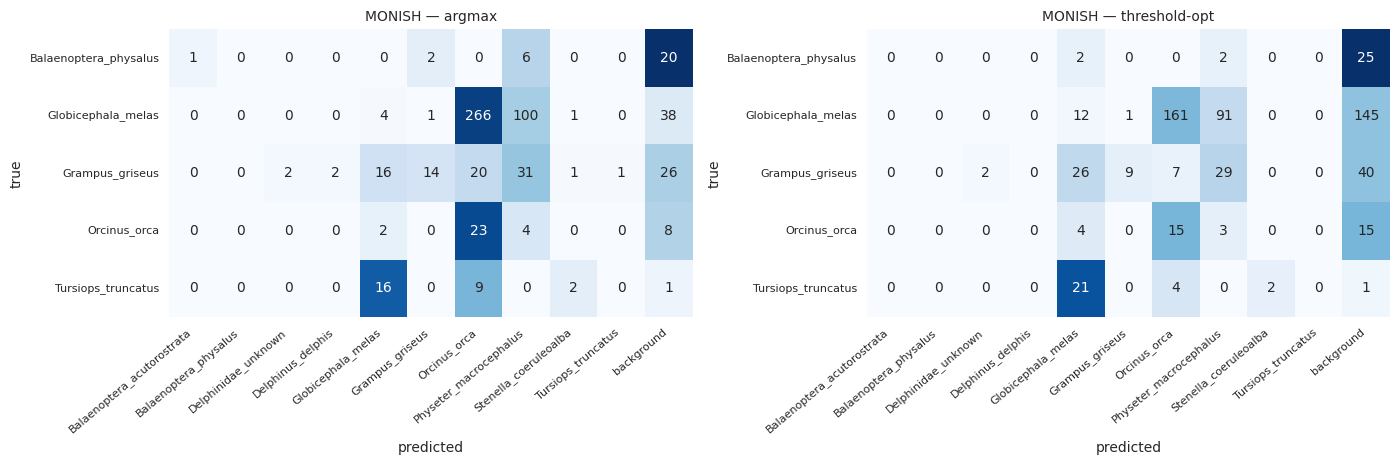


  Held out: OLTREMARE   |   classes present: ['Tursiops_truncatus', 'background']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.807     0.821    +0.014
  test_macro_f1_full_vocab           0.147     0.149    +0.003
  test_weighted_f1                   0.886     0.902    +0.016
  test_accuracy                      0.874     0.901    +0.027
  test_balanced_acc                  0.796     0.791    -0.004

  Per-class thresholds optimized on val:
    Balaenoptera_acutorostrata      t*=0.080  val_F1=1.000
    Balaenoptera_physalus           t*=0.680  val_F1=1.000
    Delphinidae_unknown             t*=0.700  val_F1=0.929
    Delphinus_delphis               t*=0.800  val_F1=0.781
    Globicephala_melas              t*=0.300  val_F1=0.436
    Grampus_griseus                 t*=0.800  val_F1=0.650
    Orcinus_orca                    t*=0.720  val_F1=0.749
    Physeter_macrocepha

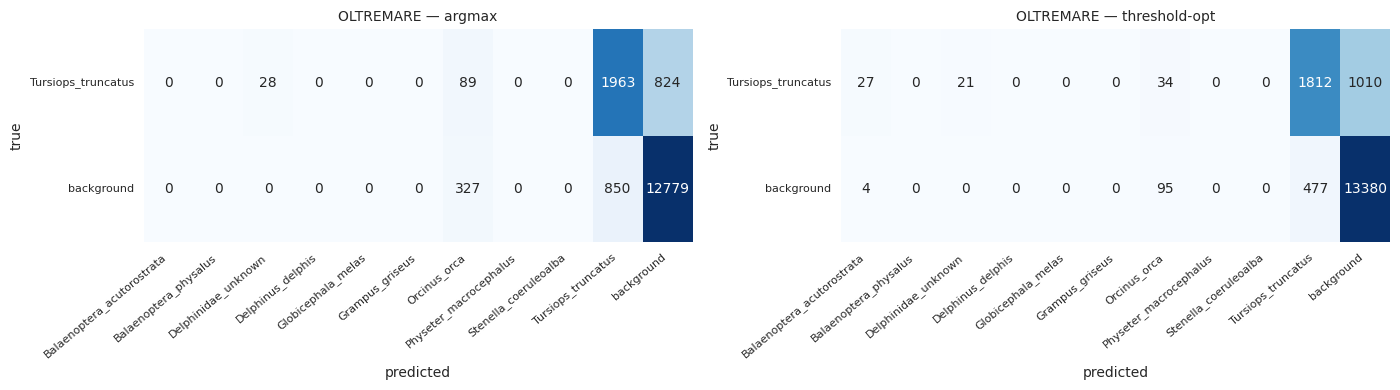


  Held out: WATKINS   |   classes present: ['Balaenoptera_physalus', 'Delphinus_delphis', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus']
  metric                            argmax   thr-opt     delta
  ----------------------------------------------------------
  test_macro_f1                      0.148     0.140    -0.008
  test_macro_f1_full_vocab           0.119     0.112    -0.007
  test_weighted_f1                   0.130     0.085    -0.045
  test_accuracy                      0.119     0.081    -0.038
  test_balanced_acc                  0.309     0.252    -0.057

  Per-class thresholds optimized on val:
    Balaenoptera_physalus           t*=0.020  val_F1=1.000
    Delphinidae_unknown             t*=0.180  val_F1=0.966
    Delphinus_delphis               t*=0.800  val_F1=0.612
    Globicephala_melas              t*=0.800  val_F1=0.502
    Grampus_griseus                 t*=0.660  val_F1=0.759
   

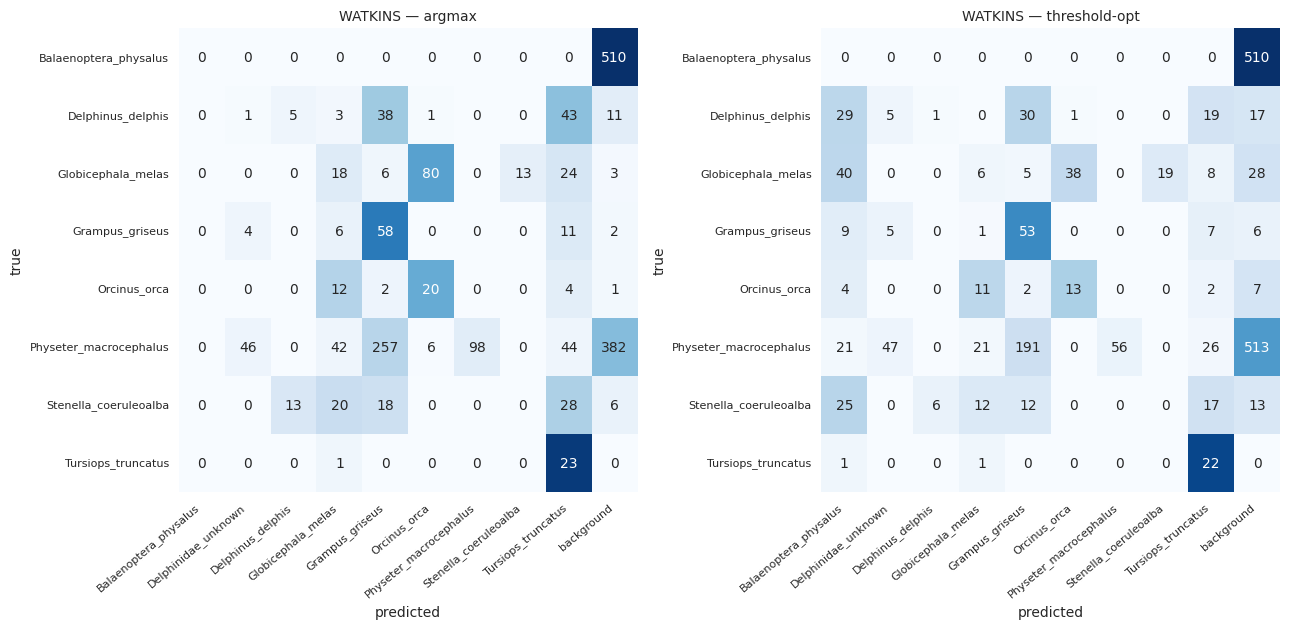

In [21]:
for ds, r in results_l4.items():
    report_comparison(ds, r['class_names'], r['yte'],
                      r['y_argmax'], r['y_thresh'],
                      r['thresholds'], r['sweep_data'])

In [22]:
summary_l4 = make_summary_df(results_l4, 'L4-species')
print("\nLevel 4 summary:")
print(summary_l4[['held_out','n_test','n_classes_test','argmax_macro_f1',
                   'thresh_macro_f1','delta_macro_f1','argmax_balanced_acc',
                   'thresh_balanced_acc']].to_string(index=False))
summary_l4.to_csv(OUT_DIR / 'summary_l4_species_lodo.csv', index=False)


Level 4 summary:
          held_out  n_test  n_classes_test  argmax_macro_f1  thresh_macro_f1  delta_macro_f1  argmax_balanced_acc  thresh_balanced_acc
         OLTREMARE   16860               2         0.807058         0.820956        0.013898             0.795814             0.791347
             DRYAD    6770               2         0.669392         0.711540        0.042148             0.598713             0.674489
      Adriatic_Sea    1180               2         0.734039         0.660828       -0.073211             0.794947             0.790563
        DCLDE_2026  174538               2         0.520592         0.536564        0.015972             0.420464             0.444033
    ECOSS_enhanced     168               6         0.529634         0.513638       -0.015996             0.514321             0.490864
   ECOSS_testtrain   36044               6         0.249268         0.410450        0.161182             0.651598             0.573716
       DOLPHINFREE    3290           

## 7. Cross-level comparison

Does threshold optimization help more at some levels than others?
Which datasets benefit most? Which hurt?

In [23]:
all_summary = pd.concat([summary_l1, summary_l2, summary_l4], ignore_index=True)
all_summary.to_csv(OUT_DIR / 'summary_all_levels.csv', index=False)

print("Overall: does threshold optimization help?")
print(all_summary.groupby('level')[['argmax_macro_f1','thresh_macro_f1',
                                    'delta_macro_f1']].mean().round(4).to_string())

Overall: does threshold optimization help?
            argmax_macro_f1  thresh_macro_f1  delta_macro_f1
level                                                       
L1-binary            0.6447           0.6308         -0.0139
L2-coarse            0.5529           0.5371         -0.0158
L4-species           0.4173           0.4189          0.0016


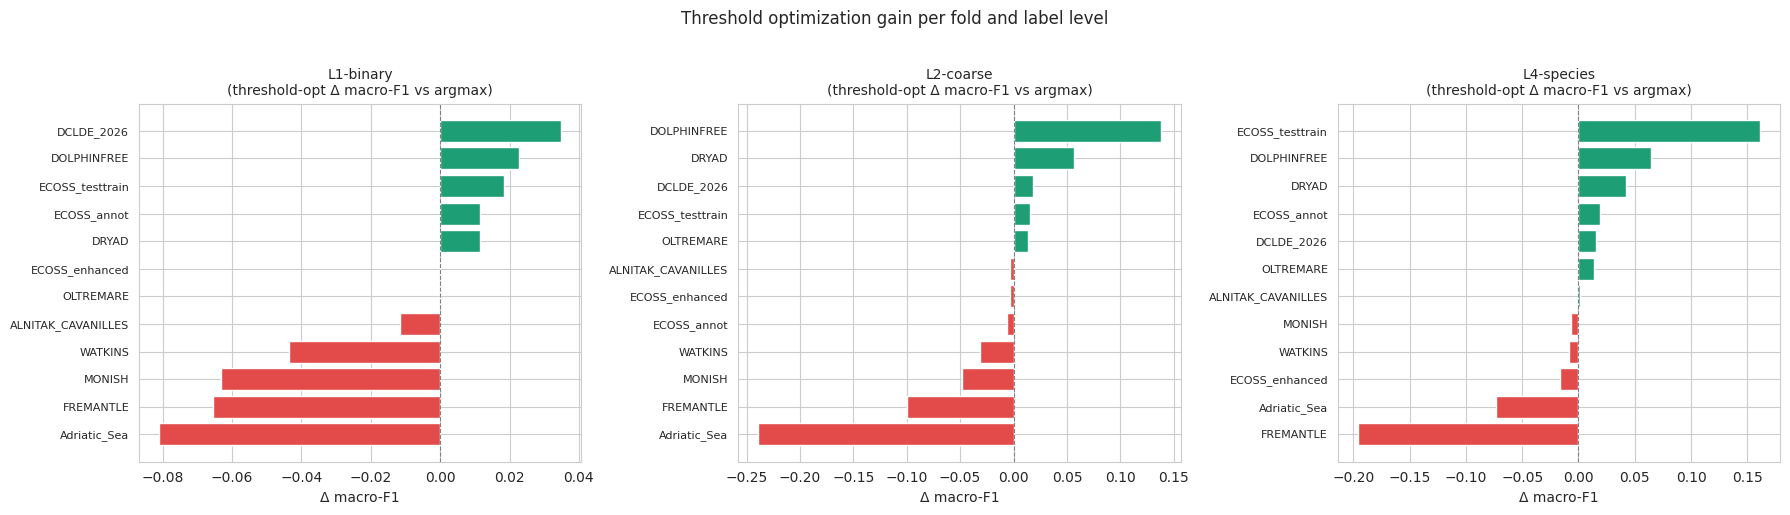

In [24]:
# ── Plot: delta macro-F1 per fold per level ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
for ax, (level, df) in zip(axes, [('L1-binary', summary_l1),
                                    ('L2-coarse',  summary_l2),
                                    ('L4-species', summary_l4)]):
    df_plot = df.sort_values('delta_macro_f1')
    colors  = ['#E24B4A' if v < 0 else '#1D9E75' for v in df_plot['delta_macro_f1']]
    ax.barh(df_plot['held_out'], df_plot['delta_macro_f1'], color=colors)
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(f'{level}\n(threshold-opt Δ macro-F1 vs argmax)', fontsize=10)
    ax.set_xlabel('Δ macro-F1')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Threshold optimization gain per fold and label level', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'threshold_delta_all_levels.png', dpi=150, bbox_inches='tight')
plt.show()

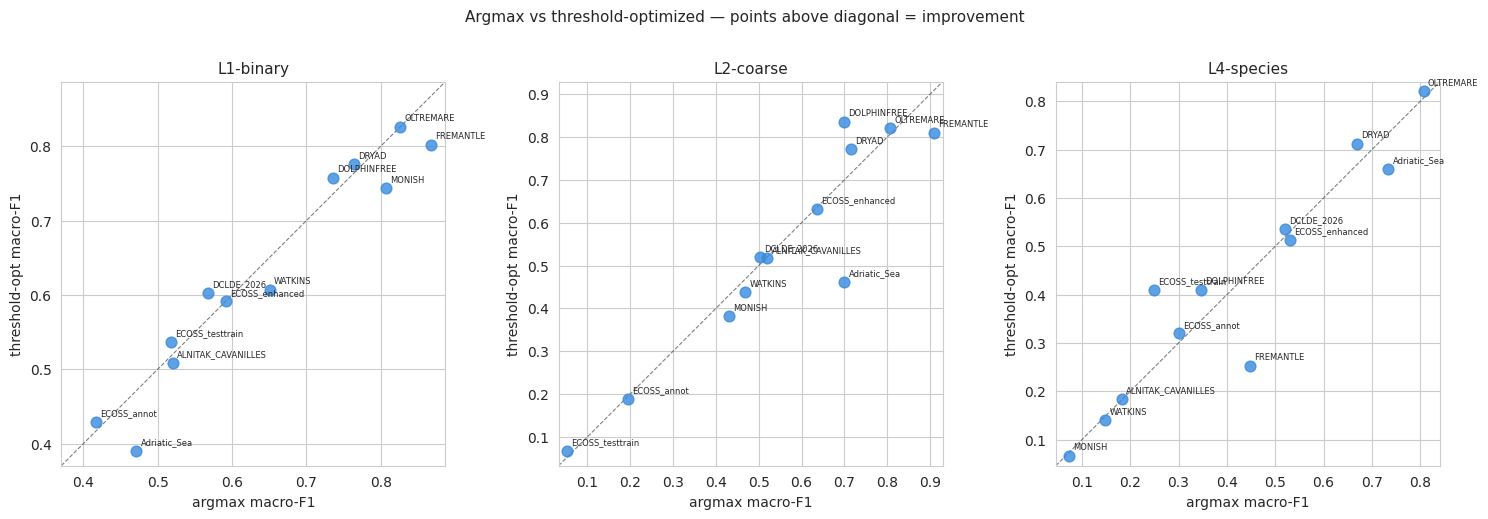

In [25]:
# ── Plot: argmax vs thresh macro-F1 scatter per level ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (level, df) in zip(axes, [('L1-binary', summary_l1),
                                    ('L2-coarse',  summary_l2),
                                    ('L4-species', summary_l4)]):
    vmin = min(df['argmax_macro_f1'].min(), df['thresh_macro_f1'].min()) - 0.02
    vmax = max(df['argmax_macro_f1'].max(), df['thresh_macro_f1'].max()) + 0.02
    ax.scatter(df['argmax_macro_f1'], df['thresh_macro_f1'],
               s=60, color='#378ADD', alpha=0.8, zorder=3)
    for _, row in df.iterrows():
        ax.annotate(row['held_out'], (row['argmax_macro_f1'], row['thresh_macro_f1']),
                    fontsize=6, ha='left', va='bottom', xytext=(3, 3),
                    textcoords='offset points')
    ax.plot([vmin, vmax], [vmin, vmax], 'k--', linewidth=0.8, alpha=0.5)  # diagonal
    ax.set_xlim(vmin, vmax); ax.set_ylim(vmin, vmax)
    ax.set_xlabel('argmax macro-F1')
    ax.set_ylabel('threshold-opt macro-F1')
    ax.set_title(f'{level}', fontsize=11)
    ax.set_aspect('equal')

plt.suptitle('Argmax vs threshold-optimized — points above diagonal = improvement',
             y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig(OUT_DIR / 'argmax_vs_thresh_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

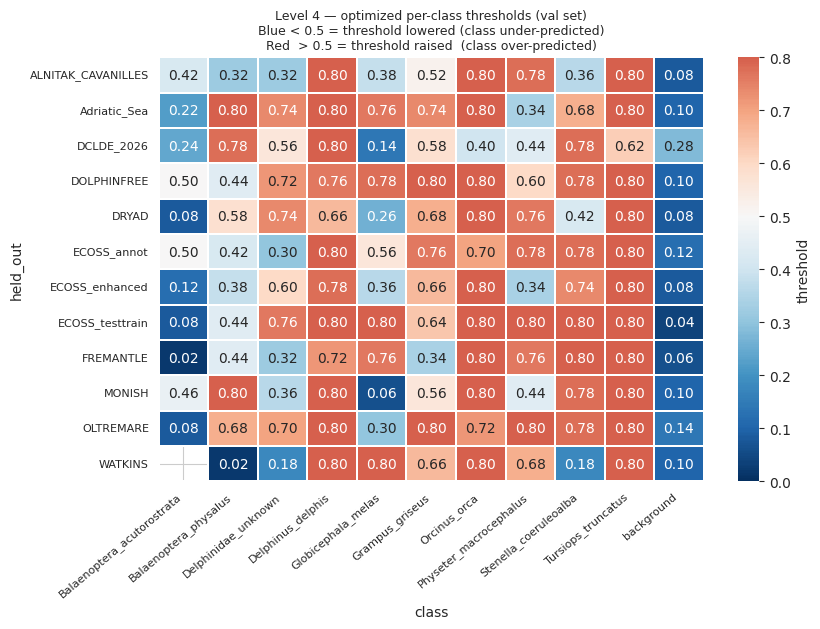

In [26]:
# ── Per-class threshold heatmap for level 4 (most interesting) ─────────────
# Shows which classes got their threshold pushed down (under-predicted) vs up.

thr_rows = []
for ds, r in results_l4.items():
    for d in r['sweep_data']:
        thr_rows.append({
            'held_out': ds,
            'class':    r['class_names'][d['class']] if d['class'] < len(r['class_names']) else str(d['class']),
            'threshold': d['best_t'],
            'val_f1':    d['best_f1'],
        })

thr_df = pd.DataFrame(thr_rows)
thr_pivot = thr_df.pivot_table(index='held_out', columns='class', values='threshold')

fig, ax = plt.subplots(figsize=(max(8, 0.6*len(thr_pivot.columns)+2),
                                 max(4, 0.45*len(thr_pivot)+1)))
sns.heatmap(thr_pivot, cmap='RdBu_r', center=0.5, vmin=0.0, vmax=0.8,
            annot=True, fmt='.2f', linewidths=0.3, ax=ax, cbar_kws={'label': 'threshold'})
ax.set_title('Level 4 — optimized per-class thresholds (val set)\n'
             'Blue < 0.5 = threshold lowered (class under-predicted)\n'
             'Red  > 0.5 = threshold raised  (class over-predicted)', fontsize=9)
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.yticks(rotation=0,  fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / 'l4_threshold_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

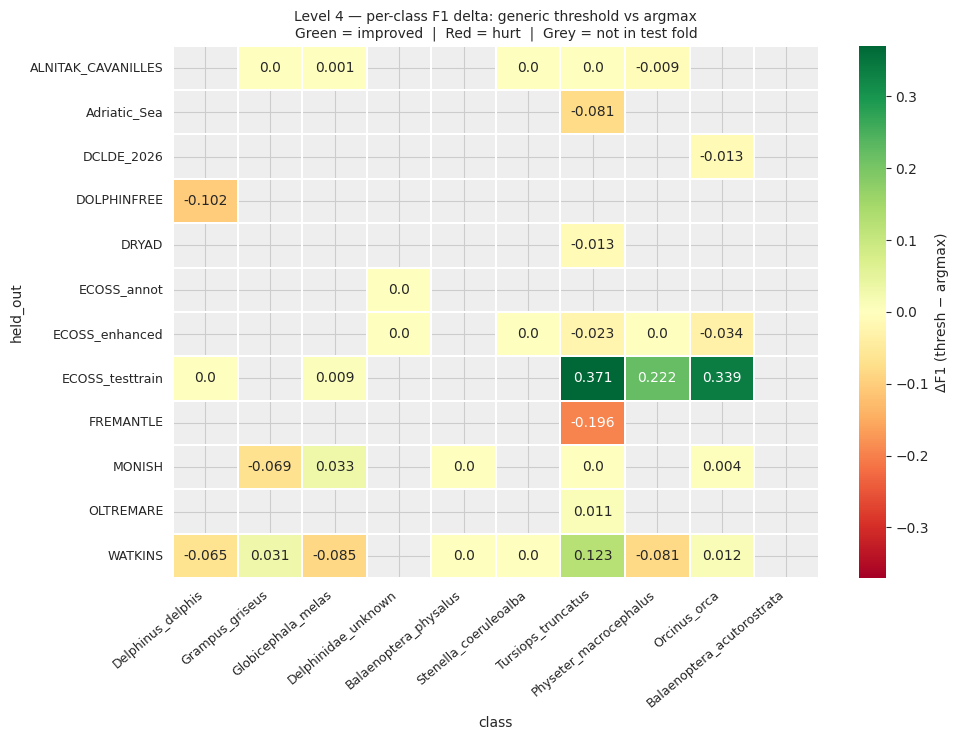


Mean delta per species (across folds where present):
class
Delphinus_delphis            -0.056
Grampus_griseus              -0.013
Globicephala_melas           -0.011
Delphinidae_unknown           0.000
Balaenoptera_physalus         0.000
Stenella_coeruleoalba         0.000
Tursiops_truncatus            0.021
Physeter_macrocephalus        0.033
Orcinus_orca                  0.062
Balaenoptera_acutorostrata      NaN


In [29]:
# Per-class F1 delta: generic threshold vs argmax
# Uses results_l4 from the OLD notebook (y_argmax, y_thresh, not y_species)

delta_rows = []
for ds, r in results_l4.items():
    class_names = r['class_names']
    bg_idx      = class_names.index('background') if 'background' in class_names else -1
    yte         = r['yte']
    present     = set(r['test_classes_present'])

    for c_idx, c_name in enumerate(class_names):
        if c_idx == bg_idx:
            continue
        if c_idx not in present:
            delta_rows.append({'held_out': ds, 'class': c_name,
                                'f1_argmax': np.nan, 'f1_thresh': np.nan,
                                'delta': np.nan, 'n_true': 0})
            continue

        f1_argmax = f1_score(yte == c_idx, r['y_argmax'] == c_idx, zero_division=0)
        f1_thresh = f1_score(yte == c_idx, r['y_thresh'] == c_idx, zero_division=0)

        delta_rows.append({
            'held_out':  ds,
            'class':     c_name,
            'f1_argmax': float(f1_argmax),
            'f1_thresh': float(f1_thresh),
            'delta':     float(f1_thresh - f1_argmax),
            'n_true':    int((yte == c_idx).sum()),
        })

delta_df    = pd.DataFrame(delta_rows)
delta_pivot = delta_df.pivot(index='held_out', columns='class', values='delta')
col_order   = delta_pivot.mean(skipna=True).sort_values().index
delta_pivot = delta_pivot[col_order]

vabs  = np.nanmax(np.abs(delta_pivot.values))
annot = delta_pivot.copy().round(3).astype(str)
annot[delta_pivot.isna()] = '—'

fig, ax = plt.subplots(figsize=(max(10, 0.75 * len(delta_pivot.columns) + 2),
                                 max(5, 0.5  * len(delta_pivot) + 1.5)))
sns.heatmap(delta_pivot, cmap='RdYlGn', center=0, vmin=-vabs, vmax=vabs,
            annot=annot, fmt='', linewidths=0.3, ax=ax,
            mask=delta_pivot.isna(),
            cbar_kws={'label': 'ΔF1 (thresh − argmax)'})
ax.set_facecolor('#eeeeee')
ax.set_title('Level 4 — per-class F1 delta: generic threshold vs argmax\n'
             'Green = improved  |  Red = hurt  |  Grey = not in test fold', fontsize=10)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'l4_f1_delta_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMean delta per species (across folds where present):")
print(delta_pivot.mean(skipna=True).round(3).sort_values().to_string())

## 8. Persist artefacts

In [27]:
def save_preds(name, r, label_col_prefix=''):
    rows_te      = r.get('rows_te')
    class_names  = r.get('class_names')
    if rows_te is None or class_names is None:
        print(f"  skip {name}: missing rows_te / class_names")
        return
    df = meta_all.iloc[rows_te][['dataset','region','environment','group_key',
                                  'label_t1','label_t2','label_t3','label_t4']].copy()
    df['y_true_idx']    = r['yte']
    df['y_true']        = [class_names[i] for i in r['yte']]
    df['y_pred_argmax'] = [class_names[i] for i in r['y_argmax']]
    df['y_pred_thresh'] = [class_names[i] for i in r['y_thresh']]
    # save softmax probabilities as separate columns
    proba = r['proba_te']
    for ci, cn in enumerate(class_names):
        df[f'prob_{cn}'] = proba[:, ci]
    fp = OUT_DIR / f'preds_{name}.parquet'
    df.to_parquet(fp, index=False)
    print(f"  saved {fp.name}  ({len(df):,} rows)")


print("Level 1:")
for ds, r in results_l1.items():
    save_preds(f'l1_{ds}', r)

print("\nLevel 2:")
for ds, r in results_l2.items():
    save_preds(f'l2_{ds}', r)

print("\nLevel 4:")
for ds, r in results_l4.items():
    save_preds(f'l4_{ds}', r)

print(f"\nAll artefacts in {OUT_DIR.resolve()}")
for fp in sorted(OUT_DIR.iterdir()):
    print(f"  {fp.name}")

Level 1:
  saved preds_l1_ALNITAK_CAVANILLES.parquet  (5,202 rows)
  saved preds_l1_Adriatic_Sea.parquet  (1,180 rows)
  saved preds_l1_DCLDE_2026.parquet  (174,538 rows)
  saved preds_l1_DOLPHINFREE.parquet  (3,290 rows)
  saved preds_l1_DRYAD.parquet  (6,770 rows)
  saved preds_l1_ECOSS_annot.parquet  (752 rows)
  saved preds_l1_ECOSS_enhanced.parquet  (168 rows)
  saved preds_l1_ECOSS_testtrain.parquet  (36,044 rows)
  saved preds_l1_FREMANTLE.parquet  (332 rows)
  saved preds_l1_MONISH.parquet  (617 rows)
  saved preds_l1_OLTREMARE.parquet  (16,860 rows)
  saved preds_l1_WATKINS.parquet  (1,877 rows)

Level 2:
  saved preds_l2_ALNITAK_CAVANILLES.parquet  (5,202 rows)
  saved preds_l2_Adriatic_Sea.parquet  (1,180 rows)
  saved preds_l2_DCLDE_2026.parquet  (174,538 rows)
  saved preds_l2_DOLPHINFREE.parquet  (3,290 rows)
  saved preds_l2_DRYAD.parquet  (6,770 rows)
  saved preds_l2_ECOSS_annot.parquet  (752 rows)
  saved preds_l2_ECOSS_enhanced.parquet  (168 rows)
  saved preds_l2_EC